In [2]:
import sys
print("Python executable:", sys.executable)

import site
print("Site-packages:", site.getsitepackages())


Python executable: /home/kirill/miniconda3/envs/DScourceNLP/bin/python
Site-packages: ['/home/kirill/miniconda3/envs/DScourceNLP/lib/python3.14/site-packages']


# Машинное обучение, DS-поток
## Задание ML.3


**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.

**Баллы за задание**

* Задача 1 &mdash; 30 баллов;
* Задача 2 &mdash; 70 баллов;
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 60 баллов;
* Задача 5 &mdash; 70 баллов.


In [ ]:
# Bot check

# HW_ID: ds_ml3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [5]:
import os

import numpy as np
import pandas as pd
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    ShuffleSplit,
    StratifiedShuffleSplit,
    GridSearchCV,
    RandomizedSearchCV,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import kagglehub

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
RANDOM_STATE=42
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from tqdm.notebook import tqdm
N_JOBS = 7
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer

sns.set_theme(style='darkgrid', palette='Paired')

---
### Задача 1

Пусть обучающая выборка $(X_1, Y_1), ..., (X_n, Y_n)$ такова, что
* объекты $X_1, ..., X_n$ одномерны и имеют распределение $\mathcal{N}(0, \sigma^2)$;
* отклик получается по правилу $Y_i = X_i^2 + \varepsilon_i$, где $\varepsilon_i$ независимы, имеют нулевое среднее и не зависят от $X_i$.

Пусть также для объекта $X$ отклик $Y$ получен по аналогичному правилу, причем $X$ и $Y$ не зависят от обучающей выборки.

Для МНК-модели $\widehat{y}(x) = \widehat{\theta} x$ выпишите подробное bias-variance разложение со всеми тремя компонентами: смещение, разброс, шум. Компоненту, отвечающую за разброс, разрешается не доводить до конца. Если в выражении присутствует дисперсия $\varepsilon_i$, то так и пишите: $\mathsf{D}\varepsilon_i$.

см. влож.

---
### Задача 2

В этой задаче вам предлагается исследовать зависимость качества предсказаний модели случайного леса в зависимости от различных гиперпараметров на примере задаче регрессии. Будем использовать класс `RandomForestRegressor` библиотеки `sklearn`.

В качестве данных возьмем датасет [**California Housing Prices**](https://www.kaggle.com/datasets/camnugent/california-housing-prices), мы уже начинали работать с ним на семинаре, продолжим его исследовать. Он содержит данные о стоимости жилья в Калифорнии. Датасет состоит из 20640 записей и содержит следующие признаки для каждого округа:

1. **Median Income** — медианный доход жителей района (в десятках тысяч долларов)
2. **Housing Median Age** — медианный возраст жилых домов (в годах)
3. **Total Rooms** — общее количество комнат
4. **Total Bedrooms** — общее количество спален
5. **Population** — численность населения района
6. **Households** — количество домохозяйств
7. **Latitude** — географическая широта
8. **Longitude** — географическая долгота
9. **Ocean proximity** — близость к океану или морю

Целевая переменная — `Median House Value` (медианная стоимость дома в районе), измеряемая в долларах США.

Наша задача будет в предсказании `Median House Value` — медианной стоимости домов в районе.

*Совет.* При отладке кода используйте небольшую часть данных. Финальные вычисления проведите на полных данных. Для оценки времени работы используйте `tqdm` в циклах.

In [90]:
import kagglehub

# Скачиваем датасет из kaggle
path = kagglehub.dataset_download("camnugent/california-housing-prices")
data = pd.read_csv(os.path.join(path, "housing.csv"))
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Разбейте данные на train и test, выделив на test 25% данных.

In [91]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [92]:
data.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

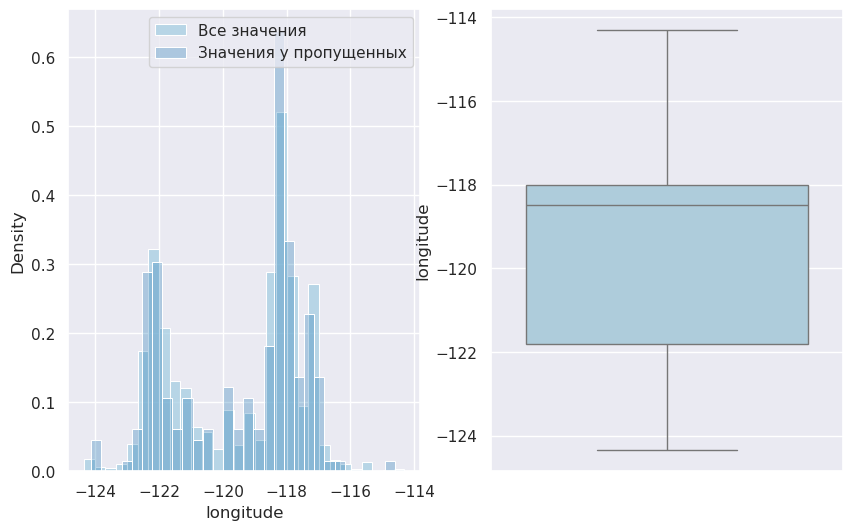

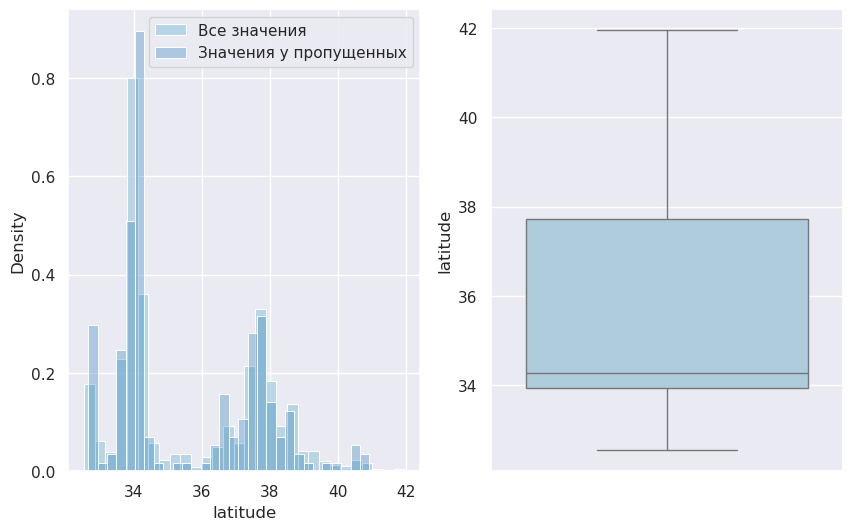

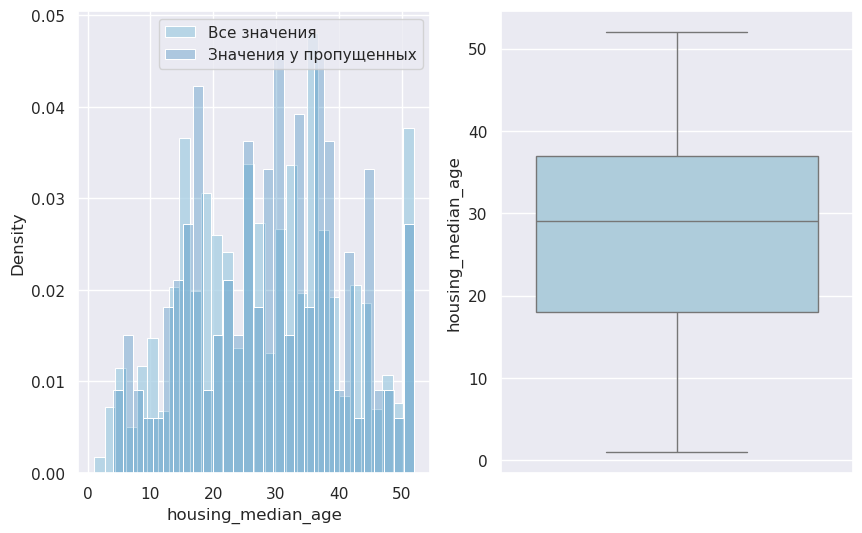

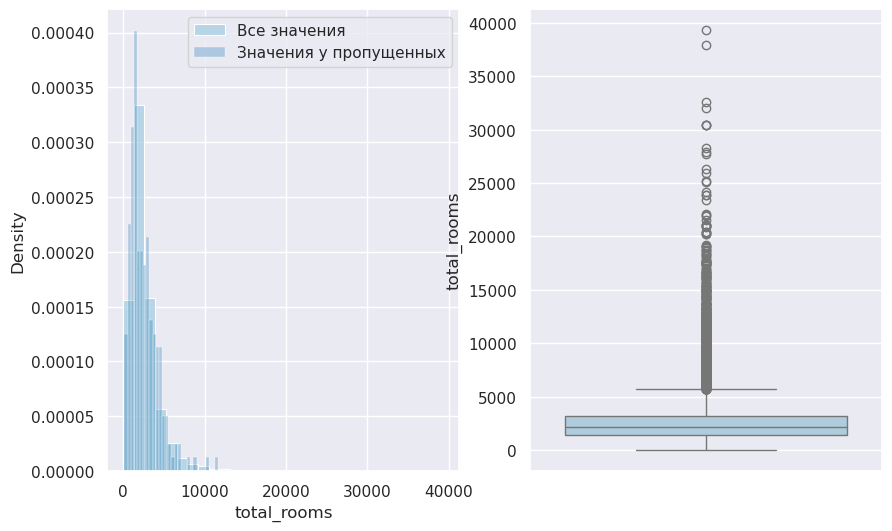

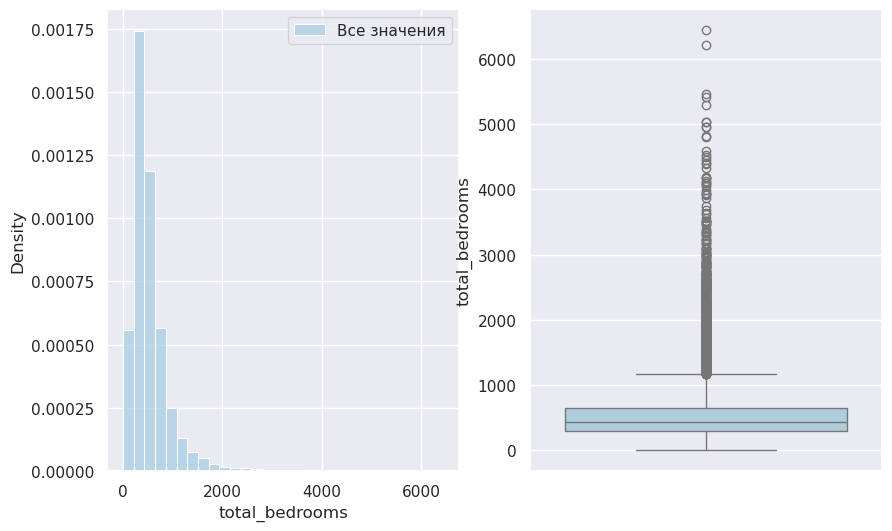

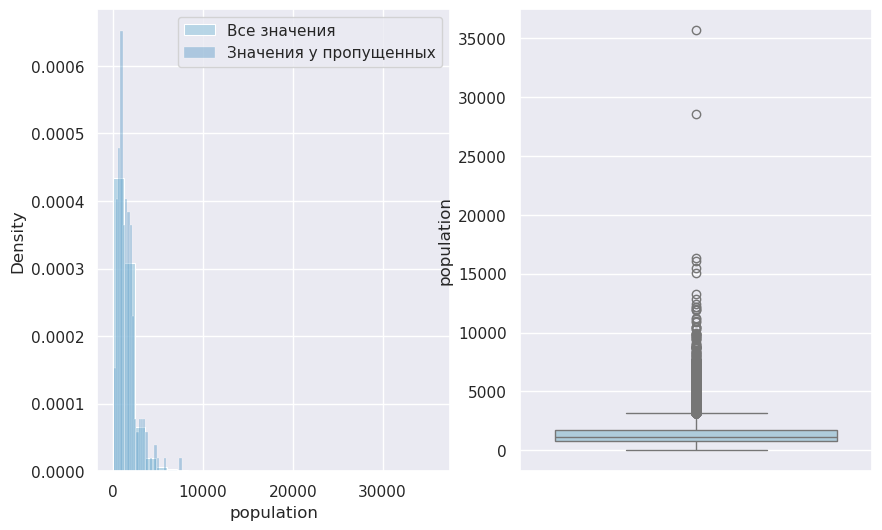

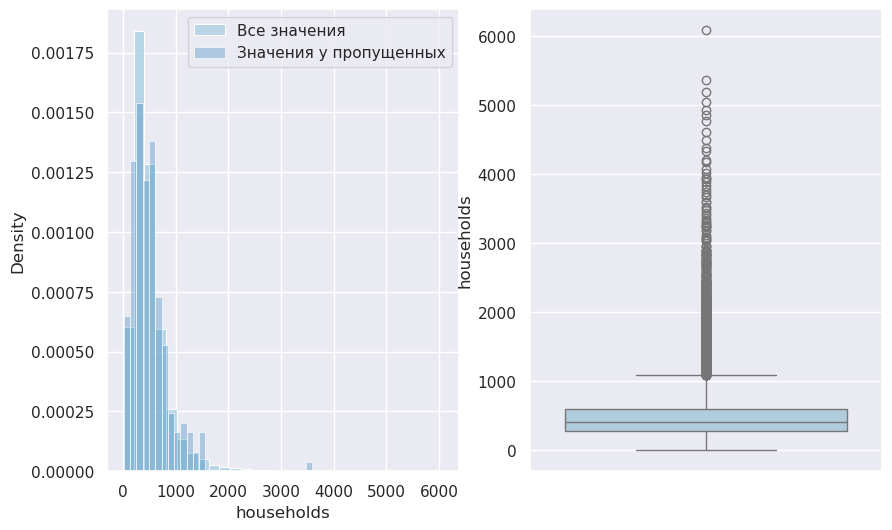

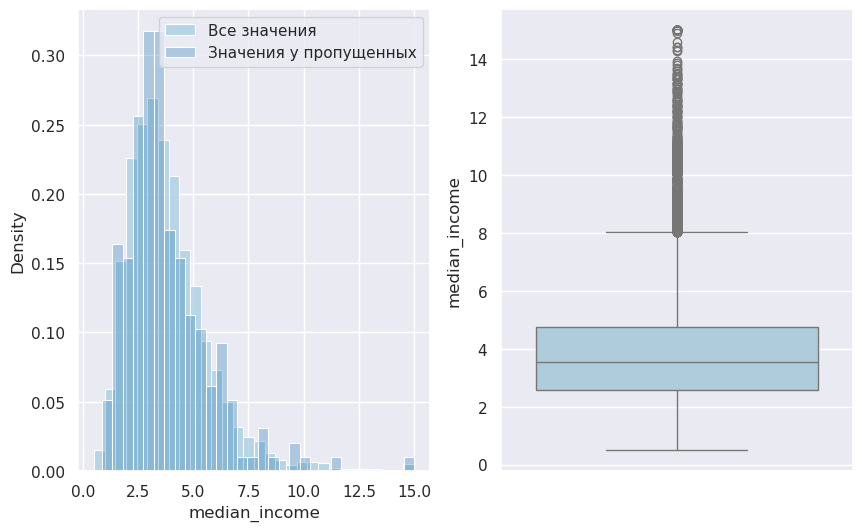

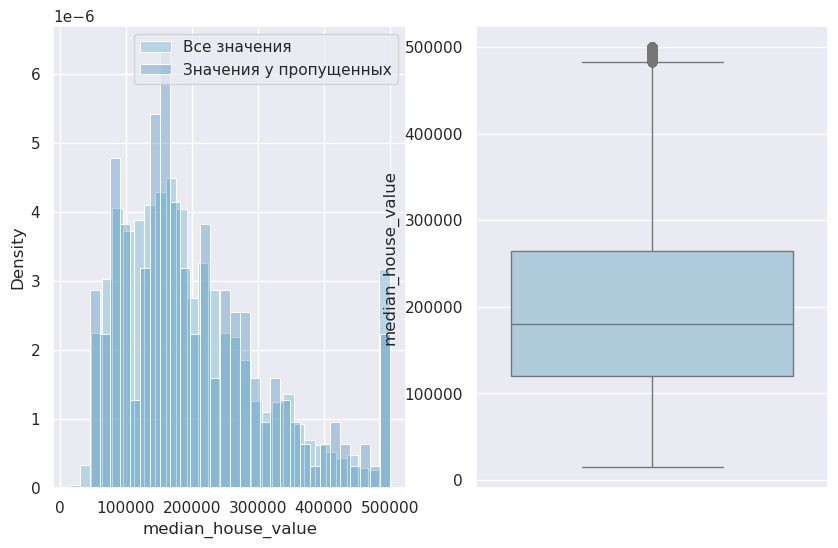

In [93]:
mask = data['total_bedrooms'].isna()
for feature in data.columns[:-1]:
    fig, ax = plt.subplots(ncols=2)
    sns.histplot(data[feature], ax=ax[0], label='Все значения', stat='density', bins=30)
    if feature != 'total_bedrooms':
        sns.histplot(data.loc[mask, feature], label='Значения у пропущенных', 
                     ax=ax[0], stat='density', bins=30, alpha=0.3)
    ax[0].legend()
    sns.boxplot(data[feature], ax=ax[1])
    
    plt.show()

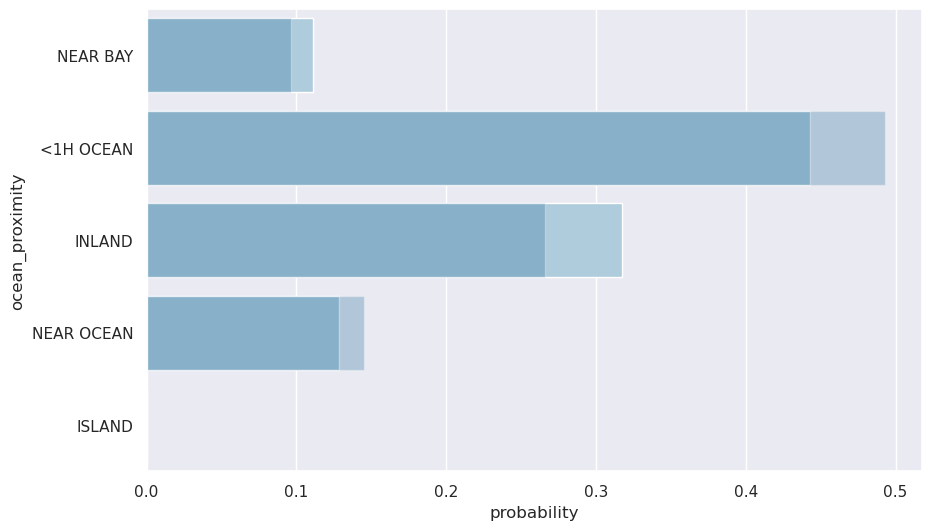

In [94]:
sns.countplot(data.loc[:, data.columns[-1]], stat='probability')
sns.countplot(data.loc[mask, data.columns[-1]], stat='probability', alpha=0.3);

Обработаем категориальную переменную

In [95]:
ohe = OneHotEncoder(sparse_output=False)
cat_encoded = ohe.fit_transform(data[['ocean_proximity']])
data = data.drop('ocean_proximity', axis=1)
data = pd.concat([data, pd.DataFrame(columns=ohe.get_feature_names_out(), data=cat_encoded)], axis=1)

Видим, что пропуски предположительно completely at random, их немного. Заменим пропуски медианой в силу обилия выбросов (см. ящик)

In [96]:
imputer = SimpleImputer(strategy='median')
data = pd.DataFrame(data=imputer.fit_transform(data), columns=data.columns)

In [97]:
data.isna().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

In [165]:
X = data.drop(['median_house_value'], axis=1)
y = data['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

Посмотрите, как изменяется качество леса в зависимости от выбранных параметров. Для этого постройте графики зависимости MSE на тестовой выборке от количества деревьев (от 1 до 100) и от максимальной глубины дерева (от 3 до 25). Когда варьируете один из параметров, в качестве другого берите значение по умолчанию.

Попробуйте получить зависимость от количества деревьев, обучив лишь **один случайный лес**. В этом вам поможет аттрибут `_estimators` у обученной модели. Последовательно вызывайте predict у каждого дерева и усредняйте полученные результаты.

In [112]:
n_grid = np.arange(1, 101)
depth_grid = np.arange(3, 26)
n_mse_test = []
n_mse_train = []
depth_mse_test = []
depth_mse_train = []

In [73]:
for n in tqdm(n_grid):
    model = RandomForestRegressor(n_estimators=n, n_jobs=N_JOBS)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    n_mse_test.append(mean_squared_error(y_pred_test, y_test))
    n_mse_train.append(mean_squared_error(y_pred_train, y_train))

  0%|          | 0/100 [00:00<?, ?it/s]

In [74]:
for depth in tqdm(depth_grid):
    model = RandomForestRegressor(max_depth=depth, n_jobs=N_JOBS)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    depth_mse_test.append(mean_squared_error(y_pred_test, y_test))
    depth_mse_train.append(mean_squared_error(y_pred_train, y_train))

  0%|          | 0/23 [00:00<?, ?it/s]

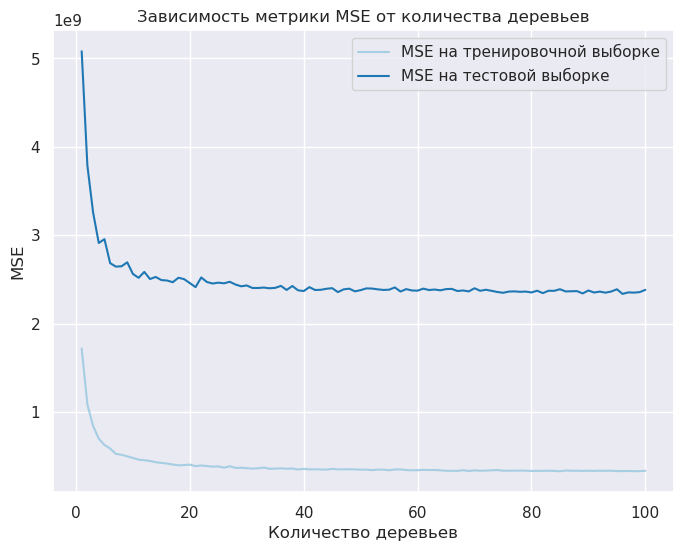

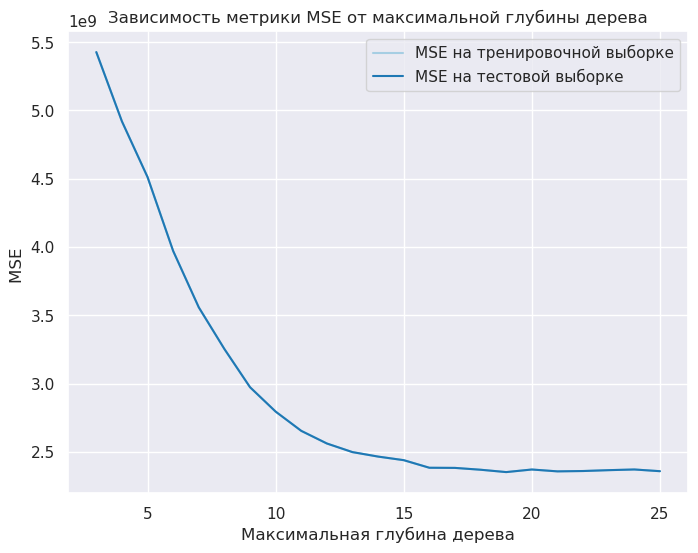

In [102]:
plt.figure(figsize=(8, 6))
plt.plot(n_grid, n_mse_train, label='MSE на тренировочной выборке')
plt.plot(n_grid, n_mse_test[1:], label='MSE на тестовой выборке')
plt.title('Зависимость метрики MSE от количества деревьев')
plt.ylabel('MSE')
plt.xlabel('Количество деревьев')
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(depth_grid, depth_mse, label='MSE на тренировочной выборке')
plt.plot(depth_grid, depth_mse, label='MSE на тестовой выборке')
plt.title('Зависимость метрики MSE от максимальной глубины дерева')
plt.ylabel('MSE ')
plt.xlabel('Максимальная глубина дерева')
plt.legend()
plt.show()

Основываясь на полученных графиках, ответьте на следующие вопросы.

1. Какие закономерности можно увидеть на построенных графиках? Почему графики получились такими?

2. Как изменяется качество предсказаний с увеличением исследуемых параметров, когда эти параметры уже достаточно большие.

3. В предыдущем задании вы на практике убедились, что решающее дерево начинает переобучаться при достаточно больших значениях максимальной глубины. Справедливо ли это утверждение для случайного леса? Поясните свой ответ, опираясь на своё знание статистики.

**Ответ:** 

Видим, что по мере увеличения каждого из параметров MSE как на тесте, так и на трейне, падает, а затем выходит на плато. Увеличение количества деревьев снижает дисперсию модели и ведет к более устойчивым результатам (хотя после некоторого значения качество перестаёт значительно расти, а время обучения увеличивается). Увеличение глубины отдельных деревьев позволяет лучше улавливать сложные зависимости в данных без сильного риска переобучения, так как усреднение в лесу сглаживает переобучение каждого дерева. Если данные очень шумные, то с увеличением глубины появляется риск переобучения, но не в нашем случае, метрика выходит на плато


Обучите случайный лес с параметрами по умолчанию и выведите MSE на тестовой выборке. Проведите эксперимент 3 раза. Почему результаты отличаются? Какие источники случайности есть при построении случайного леса и какие из них реализуются в данном случае?

In [106]:
model = RandomForestRegressor()
m = 3
for i in tqdm(range(m)):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'MSE на тестовой выборке {i + 1}: {mean_squared_error(y_pred, y_test)}')

  0%|          | 0/3 [00:00<?, ?it/s]

MSE на тестовой выборке 1: 2323172426.18296
MSE на тестовой выборке 2: 2343777735.91595
MSE на тестовой выборке 3: 2330173758.1650186


**Ответ:** В данном случае случайность возникает из случайного выбора признаков для построения отдельных глубоких деревье

Было бы неплохо определиться с тем, какое количество деревьев нужно использовать и какой максимальной глубины они будут. Подберите оптимальные значения `max_depth` и `n_estimators` с помощью кросс-валидации.

Чтобы не было порядка в данных, поставим shuffle=True. Поэтому будем использовать обычный K-fold. Подбирать количество деревьев будем так, что при дальнейшем его увеличении метрика меняется слабо. Аналогично для глубины

In [115]:
n_mse = []
depth_mse = []

In [118]:
cv = KFold(n_splits=5, shuffle=True)
for n in tqdm(n_grid):
    model = RandomForestRegressor(n_estimators=n, n_jobs=N_JOBS)
    score = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=metrics.make_scorer(mean_squared_error, greater_is_better=False),
    )
    n_mse.append(score.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

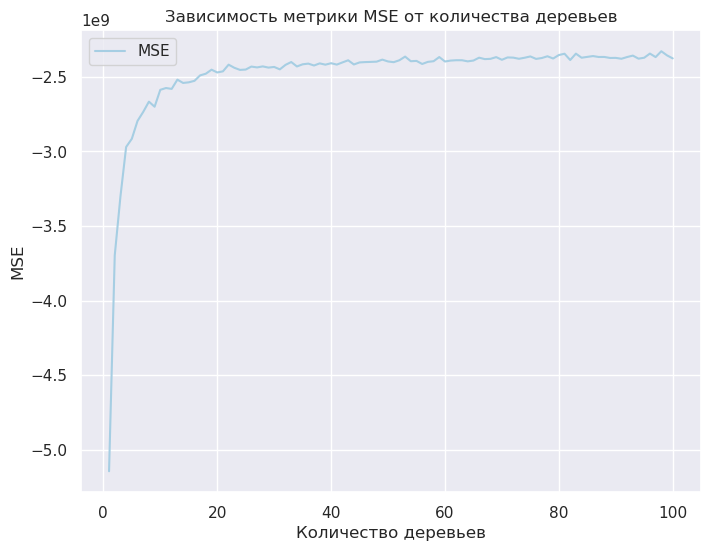

In [120]:
plt.figure(figsize=(8, 6))
plt.plot(n_grid, n_mse, label='MSE')
plt.title('Зависимость метрики MSE от количества деревьев')
plt.ylabel('MSE')
plt.xlabel('Количество деревьев')
plt.legend()
plt.show()

Как и ожидалось, чем больше деревьев, тем лучше метрика

In [121]:
n = 100
for depth in tqdm(depth_grid):
    model = RandomForestRegressor(n_estimators=n, max_depth=depth, n_jobs=N_JOBS)
    score = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=metrics.make_scorer(mean_squared_error, greater_is_better=False),
    )
    depth_mse.append(score.mean())

  0%|          | 0/23 [00:00<?, ?it/s]

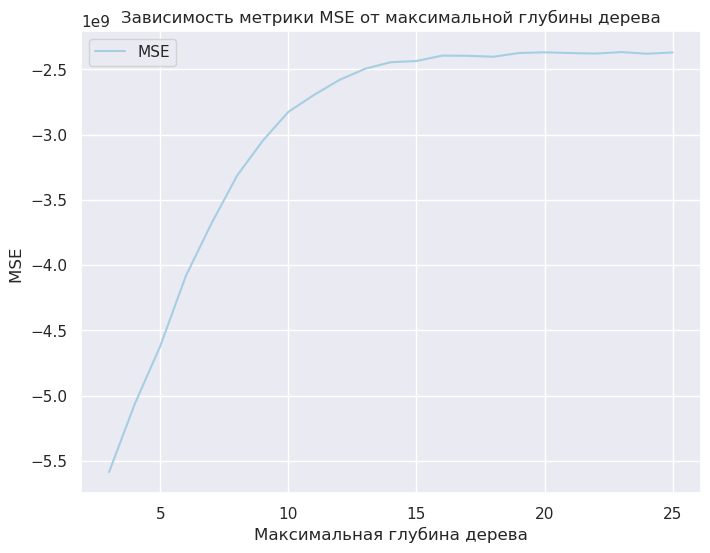

In [131]:
plt.figure(figsize=(8, 6))
plt.plot(depth_grid, depth_mse, label='MSE')
plt.title('Зависимость метрики MSE от максимальной глубины дерева')
plt.ylabel('MSE ')
plt.xlabel('Максимальная глубина дерева')
plt.legend()
plt.show()

Выведите найденные оптимальные параметры.

In [124]:
depth = 20

print(f'Наилучшие параметры:\nГлубина:{depth}\nКоличество деревьев:{n}')

Наилучшие параметры:
Глубина:20
Количество деревьев:100


Зафиксируем эти оптимальные значения параметров и в дальнейшим будем их использовать.

In [125]:
max_depth = depth
n_estimators = n

Оценим качество предсказаний обученного решающего леса.

In [135]:
model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=N_JOBS)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('MSE:', mean_squared_error(y_pred, y_test))

MSE: 2420057899.3972626


Исследуйте зависимость метрики MSE от количества признаков, по которым происходит разбиение в вершине дерева. Поскольку количество признаков в датасете не очень большое (их 8), то можно перебрать все возможные варианты количества признаков, использующихся при разбиении вершин.

Не забывайте делать пояснения и выводы!

In [130]:
f_mse = []
f_grid = np.arange(1, 9)
for f in tqdm(f_grid):
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, max_features=f, n_jobs=N_JOBS)
    score = cross_val_score(
        estimator=model,
        X=X,
        y=y,
        cv=cv,
        scoring=metrics.make_scorer(mean_squared_error, greater_is_better=False),
    )
    f_mse.append(score.mean())

  0%|          | 0/8 [00:00<?, ?it/s]

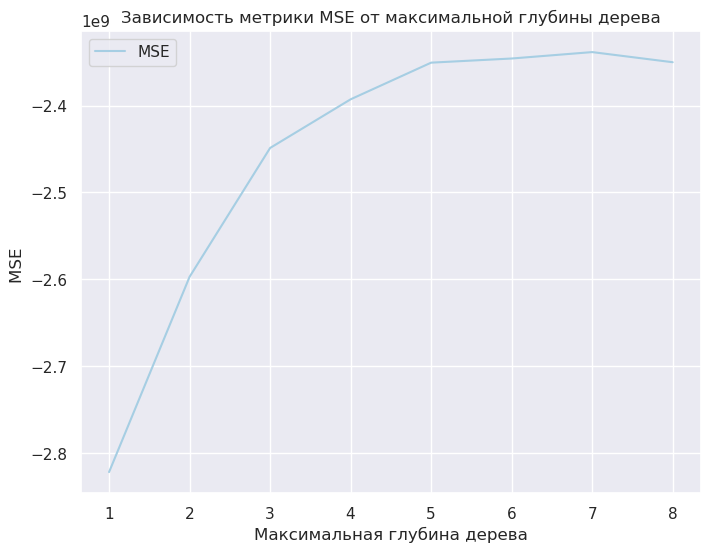

In [136]:
plt.figure(figsize=(8, 6))
plt.plot(f_grid, f_mse, label='MSE')
plt.title('Зависимость метрики MSE от максимальной глубины дерева')
plt.ylabel('MSE ')
plt.xlabel('Максимальная глубина дерева')
plt.legend()
plt.show()

Постройте график зависимости метрики MSE на `test` и `train` в зависимости от числа признаков, использующихся при разбиении в каждой вершине.

In [143]:
f_mse_train = []
f_mse_test = []
for f in tqdm(f_grid):
    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=depth, max_features=f, n_jobs=N_JOBS)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    f_mse_test.append(mean_squared_error(y_pred_test, y_test))
    f_mse_train.append(mean_squared_error(y_pred_train, y_train))

  0%|          | 0/8 [00:00<?, ?it/s]

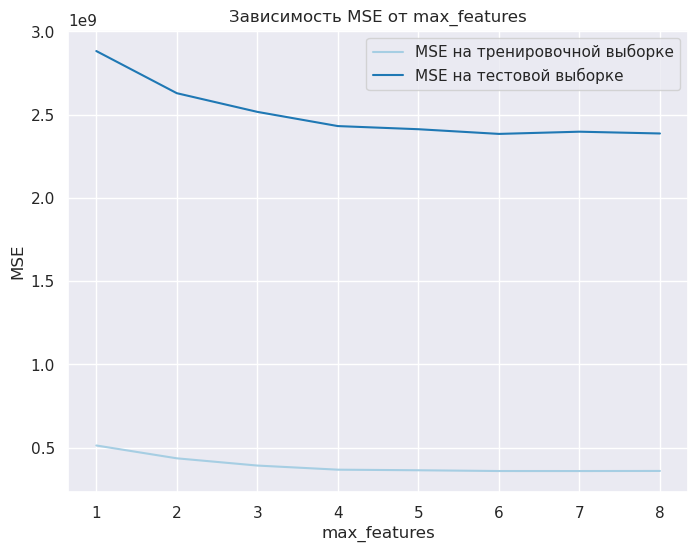

In [144]:
plt.figure(figsize=(8, 6))
plt.plot(f_grid, f_mse_train, label='MSE на тренировочной выборке')
plt.plot(f_grid, f_mse_test, label='MSE на тестовой выборке')
plt.title('Зависимость MSE от max_features')
plt.ylabel('MSE')
plt.xlabel('max_features')
plt.legend()
plt.show()

Почему график получился таким? Как зависит разнообразие деревьев, инными словами их скоррелированность, от величины `n_features`?

**Ответ:** 

1. При увеличении max_features становится больше пересечений в обучающих множествах, поэтому деревья становятся более скореллированными, а значит variance растёт.
2. Однако большее количество признаков позволяет каждой модели улавливать более сложные зависимости, поэтому bias уменьшается. Также уменьшается дисперсия каждой отдельной модели, ведь уменьшается случанойсть в выборе признаков
3. Видимо, эффект от пункта 2 выше, поэтому суммарная ошибка падает

Проведите эксперимент, в котором выясните, как изменится качество регрессии, если набор признаков, по которым происходит разбиение в каждой вершине определяется не заново в каждой вершине, а задан заранее для всего дерева. То есть перед каждым построением дерева выбирается новый набор признаков, который будет рассматриваться при построении всех разбиений в этом дереве.

Для реализации данного эксперимента используйте класс беггинг-модели `sklearn.ensemble.BaggingRegressor`, у которого используйте следующие поля:
* `base_estimator` — базовая модель, используйте `sklearn.tree.DecisionTreeRegressor`;
* `max_features` — количество признаков для каждой базовой модели;
* `n_estimators` — количество базовых моделей.

Постройте графики MSE на обучающей и на валидационной выборке в зависимости от числа рассматриваемых признаков в дереве.

In [145]:
f_mse_train_bag = []
f_mse_test_bag = []
for f in tqdm(f_grid):
    model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n_estimators, max_features=f, n_jobs=N_JOBS)
    model.fit(X_train, y_train)
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    f_mse_test_bag.append(mean_squared_error(y_pred_test, y_test))
    f_mse_train_bag.append(mean_squared_error(y_pred_train, y_train))

  0%|          | 0/8 [00:00<?, ?it/s]

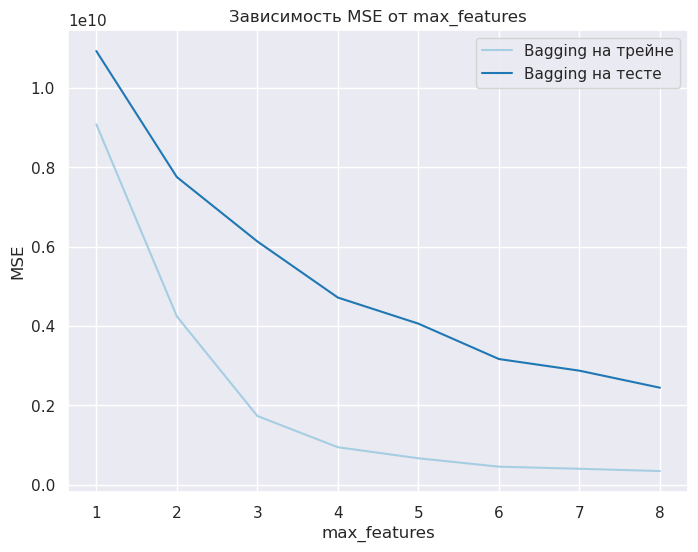

In [149]:
plt.figure(figsize=(8, 6))
plt.plot(f_grid, f_mse_train_bag, label='Bagging на трейне')
plt.plot(f_grid, f_mse_test_bag, label='Bagging на тесте')
plt.title('Зависимость MSE от max_features')
plt.ylabel('MSE')
plt.xlabel('max_features')
plt.legend()
plt.show()

Сравните результаты обычного случайного леса с только что построенным лесом.

Сделайте выводы. Объясните, чем плох такой подход пострения случайного леса. Какое преимущество мы получаем, когда выбираем случайное подмножество признаков в каждой вершине в обычном случайном лесу? Опирайтесь в своих рассуждениях на bias-variance разложение.

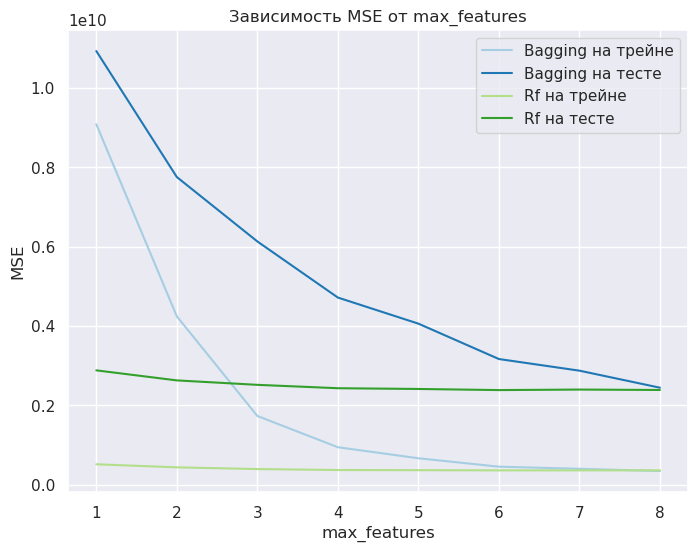

In [148]:
plt.figure(figsize=(8, 6))
plt.plot(f_grid, f_mse_train_bag, label='Bagging на трейне')
plt.plot(f_grid, f_mse_test_bag, label='Bagging на тесте')
plt.plot(f_grid, f_mse_train, label='Rf на трейне')
plt.plot(f_grid, f_mse_test, label='Rf на тесте')
plt.title('Зависимость MSE от max_features')
plt.ylabel('MSE')
plt.xlabel('max_features')
plt.legend()
plt.show()

**Вывод.**

1. При таком подходе увеличивается скоррелированность моделей, потому что увеличивается пересечение обучаемых множеств. Поэтому увеличивается variance. Остальные параметры примерно не меняются.
2. Заметим, что при max_features = 8 значения метрики парктически свопадают, как и должно быть

Поясните разницу между следующими конструкциями:

`BaggingRegressor(base_estimator=DecisionTreeRegressor(), max_features=n_features)`

`BaggingRegressor(base_estimator=DecisionTreeRegressor(max_features=n_features))`

В первом варианте для обучения каждого отдельного перева берётся одинаковое количество признаков для обучения, равное n_feature, а само дерево строится на этих признаках уже без ограничений на max_feature, так как иницилизируется с деволтным параметром None. Во втором - уже сам бэггинг инициализируется с дефолтным параметром max_features = 1, то есть для обучения каждого отдельного дерева на вход выбирается один случайный признак, и дерево на нём учится

---
### Задача 3

На лекции получена формула bias-variance разложения для беггинга. Проведите эксперимент, в котором выясните, насколько уменьшается разброс (variance-компонента) беггинг-модели на 100 базовых моделях по отношению к одной базовой модели. Используйте данные из предыдущей задачи. Рассмотрите беггинг на следующих базовых моделях:
* решающие деревья, можно использовать вариант случайного леса,
* ридж-регрессия.

Для решения задачи потребуется оценить корреляции предсказаний на тестовой выборке базовых моделей, входящих в состав беггинг-модели. Их можно получить с помощью поля `estimators_` у обученной беггинг-модели. Для оценки корреляций используйте [`scipy.stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) или [`numpy.corrcoef`](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html).

Насколько уменьшается разброс в каждом случае? Для каждого случая постройте также матрицу корреляций предсказаний базовых моделей и гистограмму по ним.

In [235]:
def preds_variance(model, X_test, ddof=0):
    preds = np.vstack([est.predict(X_test) for est in model.estimators_])
    n = preds.shape[0]
    C = np.cov(preds, ddof=ddof)
    var_mean = C.sum() / (n ** 2)
    
    if n > 1:
        sns.heatmap(np.corrcoef(preds))
        plt.show()
    return preds.mean(axis=0), var_mean

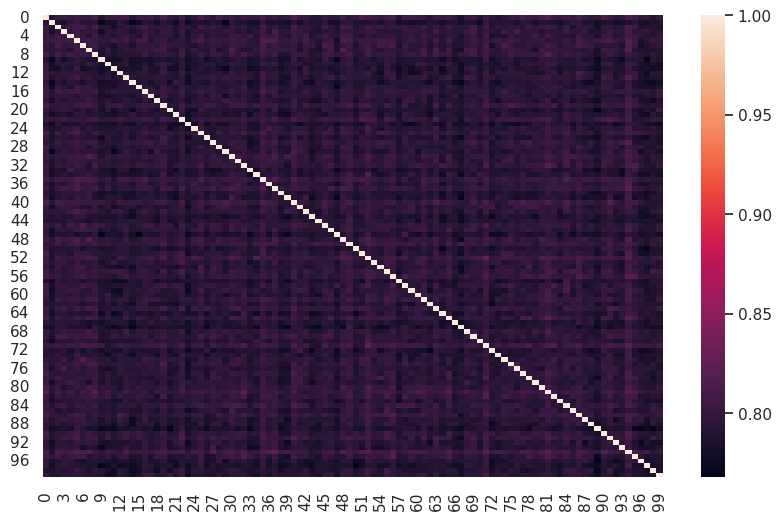

Var(mean), n=1: 13105443481.001013
Var(mean), n=100: 10583309588.72383


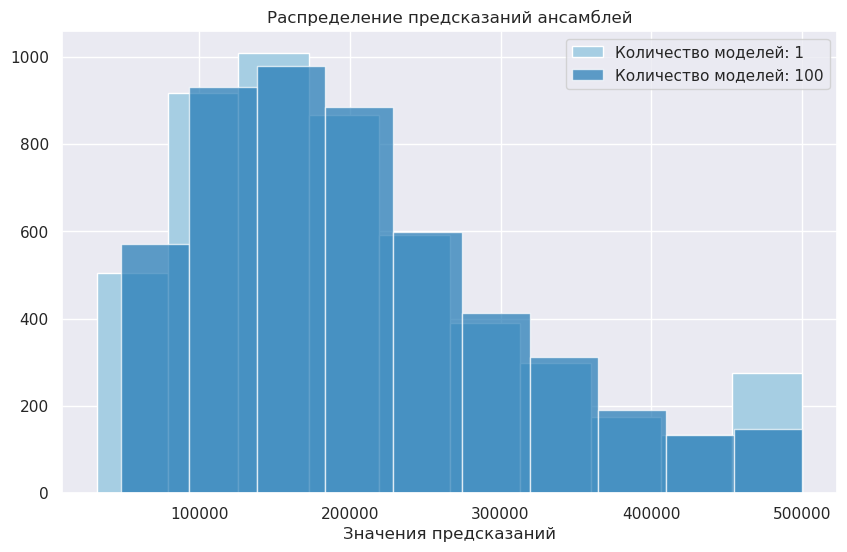

In [246]:
n1 = 1
model1 = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n1, n_jobs=N_JOBS, random_state=42)
model1.fit(X_train.to_numpy(), y_train.to_numpy())
preds1, variance1 = preds_variance(model1, X_test.to_numpy(), ddof=1)

n2 = 100
model2 = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=n2, n_jobs=N_JOBS, random_state=42)
model2.fit(X_train.to_numpy(), y_train.to_numpy())
preds2, variance2 = preds_variance(model2, X_test.to_numpy(), ddof=1)

print("Var(mean), n=1:", variance1)
print("Var(mean), n=100:", variance2)

plt.figure()
plt.hist(preds1, label=f'Количество моделей: {n1}')
plt.hist(preds2, label=f'Количество моделей: {n2}', alpha=0.7)
plt.title('Распределение предсказаний ансамблей')
plt.xlabel('Значения предсказаний')
plt.legend()
plt.show()

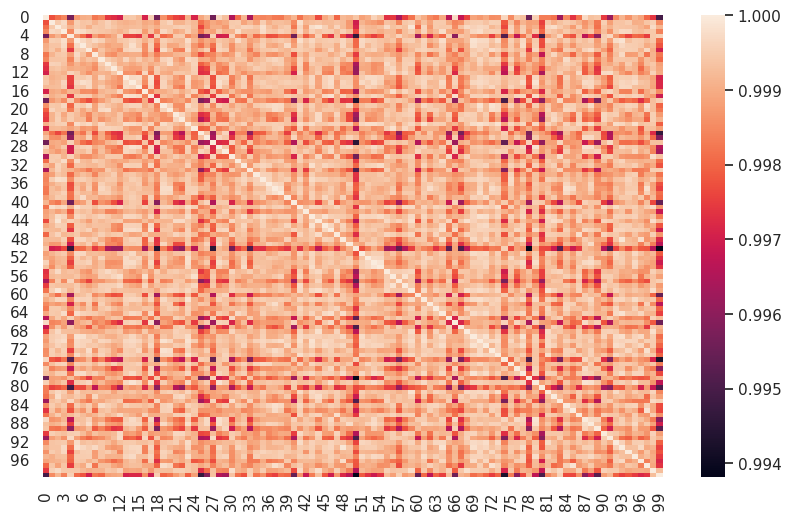

Var(mean), n=1: 8415716480.28
Var(mean), n=100: 8730937997.81


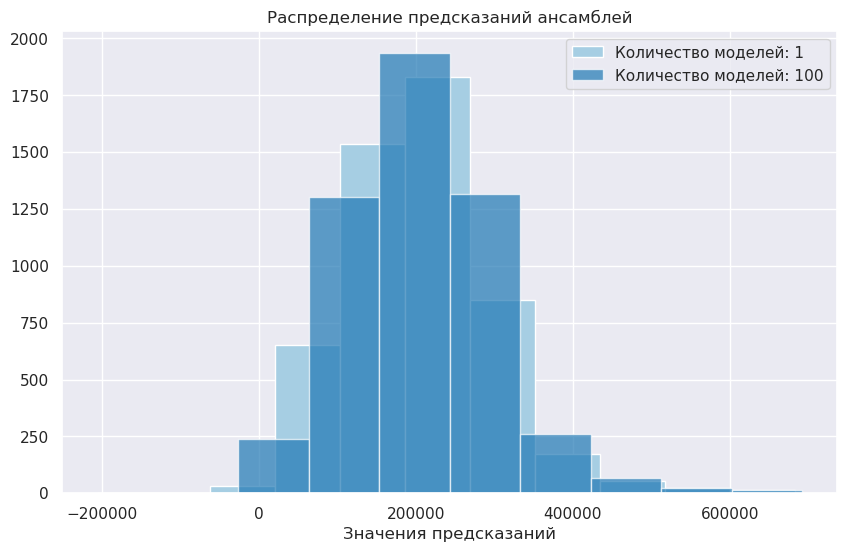

In [247]:
n1 = 1
model1 = BaggingRegressor(estimator=Ridge(), n_estimators=n1, n_jobs=N_JOBS, random_state=42)
model1.fit(X_train.to_numpy(), y_train.to_numpy())
preds1, variance1 = preds_variance(model1, X_test.to_numpy(), ddof=1)

n2 = 100
model2 = BaggingRegressor(estimator=Ridge(), n_estimators=n2, n_jobs=N_JOBS, random_state=42)
model2.fit(X_train.to_numpy(), y_train.to_numpy())
preds2, variance2 = preds_variance(model2, X_test.to_numpy(), ddof=1)

print(f"Var(mean), n=1: {variance1:.2f}")
print(f"Var(mean), n=100: {variance2:.2f}")

plt.figure()
plt.hist(preds1, label=f'Количество моделей: {n1}')
plt.hist(preds2, label=f'Количество моделей: {n2}', alpha=0.7)
plt.title('Распределение предсказаний ансамблей')
plt.xlabel('Значения предсказаний')
plt.legend()
plt.show()

В первом случае разброс действительно уменьшается, это связано с увеличением количества моделеё и с небольшой их папрной корреляций ввиду особенностей модели дерева. Во втором случае разброс увеличивается, что неудивительно, ведь множество линейных моделей на одних и тех же данных будут выдавать очень линейно-скоррелированные предсказания. Это подтверждается и матрицей корреляций

---
### Задача 4

В этой задаче вам предлагается расмотреть и сравнить две стратегии поиска оптимальных значений некоторого функционала: **Grid Search** и **Random Search**. В реальной жизни значение функционала &mdash; это значение целевой метрики качества, а оптимизация идет по гиперпараметрам некоторой модели машинного обучения. Коротко напомним, в чем же заключается каждая стратегия.

* **Grid Search** &mdash; полный перебор по сетке. Суть перебора по сетке заключается в следующем: вы задаете область значений гиперпараметров, которые хотите оптимизировать, обучаете все модели, которые возможно получить в рамках заданного пространства поиска гиперпараметров. Затем выбираете из данных моделей ту, которая дала наилучшее качество на кросс-валидации.
* **Random Search** &mdash; это стратегия, при которой рассматривается некоторая выборка из множества значений гиперпараметров. По умолчанию часто используется равномерное распределение. Лучшая модель выбирается так же на основе кросс-валидации.

Разберем сначала **одномерный случай**. Для этого рассмотрим следующую функцию.

In [248]:
def f(x):
    return 5.2 - 5/(1+(3*(x))**2) - np.cos(x)/5

Поcтройте график функции $f(x)$ на отрезке $[-20, 20]$. В чем его особенность?

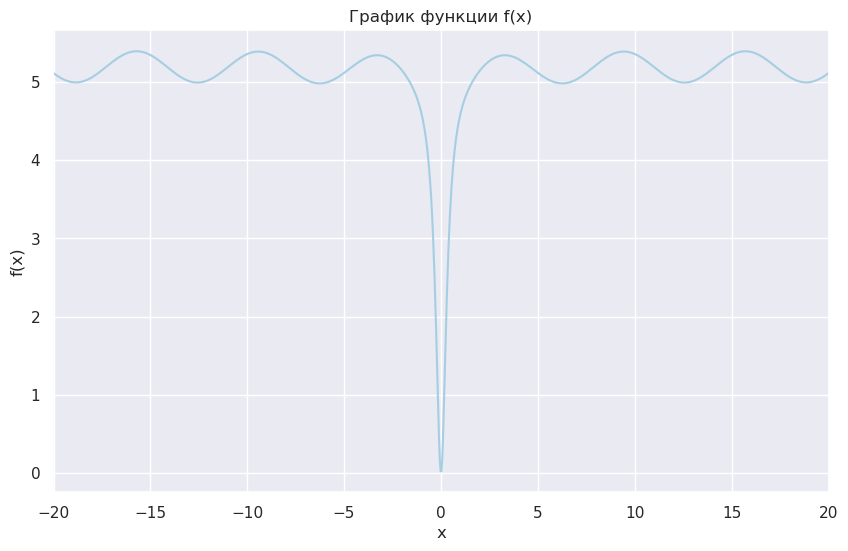

In [249]:
x = np.linspace(-20, 20, 1000)
plt.plot(x, f(x))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('График функции f(x)')
plt.xlim(-20, 20)
plt.show()

Подумайте, какие проблемы могут возникнуть при поиске минимума этой функции, если используется поиск по сетке?

**Ответ:**  Допустим если мы ищем минимум функции. Тогда при слишком маленьком шаге мы будем оставаться в локальных минимумах, не доходя до глобальных, а при слишком большом - перескакивать его.

Рассмотрим **поиск по сетке** и проведем вычислительный эксперимент. Для этого будем генерировать случайное смещение из $U[-0.5, 0.5]$, а затем рассматривать смещенную на $x_0$ сетку размера $n$ на отрезке $[-10, 10]$, после чего поиском по сетке искать оптимальное значение $f$.

In [250]:
# рассматриваемые размеры сеток
grid_size = np.arange(2, 1000)
n_experiments = 100  # количество экспериментов

In [251]:
# массив для минимумов по сетке для текущего эксперимента
grid_min_f_trace = []

for _ in tqdm(range(n_experiments)):
    # случайное смещение сетки на [-0.5, 0.5]
    x_0 = sps.uniform.rvs(loc=-0.5, scale=1)
    # массив для минимумов для текущего размера сетки
    grid_f_min = []
    # цикл по размеру сетки
    for n in grid_size:
        # сетка на [-10, 10] размера n
        grid = np.linspace(-10, 10, n)
        # найденный по сетке со смещением x_0 минимум функции f
        f_min = min(f(grid + x_0))
        # сохраним минимум для сетки размера n
        grid_f_min.append(f_min)
    # сохраним минимумы текущего эксперимента
    grid_min_f_trace.append(grid_f_min)

  0%|          | 0/100 [00:00<?, ?it/s]

Для нескольких экспериментов постройте графики значений минимума от количества точек в сетке.
Для большей наглядности и информативности сразу **зафиксируйте диапазон значений по оси y**, а также отображайте графики в **логарифмическом масштабе**.

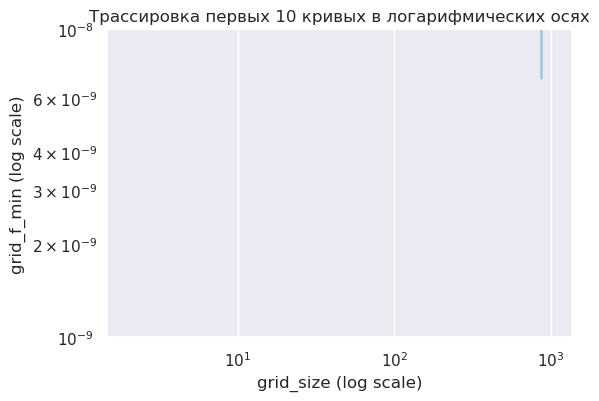

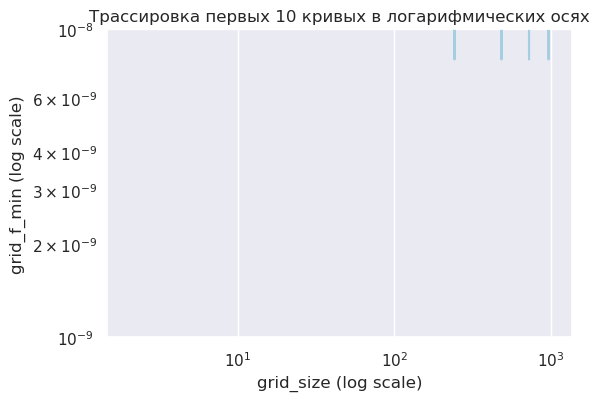

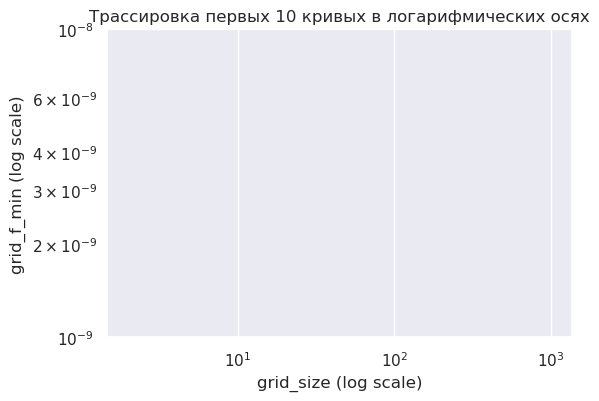

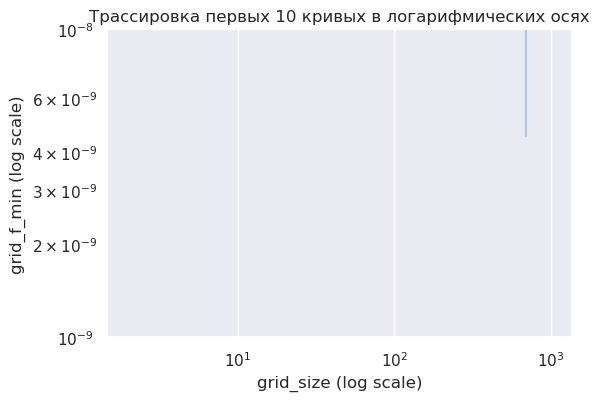

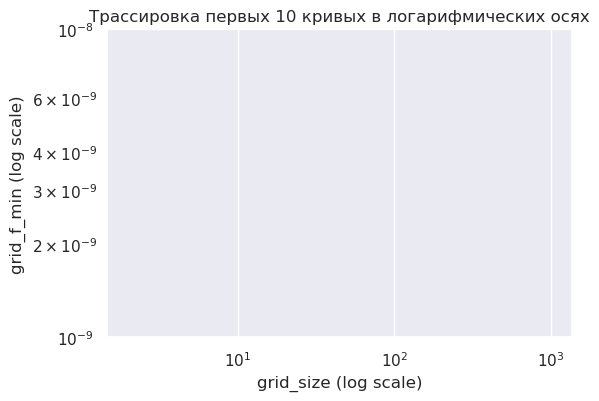

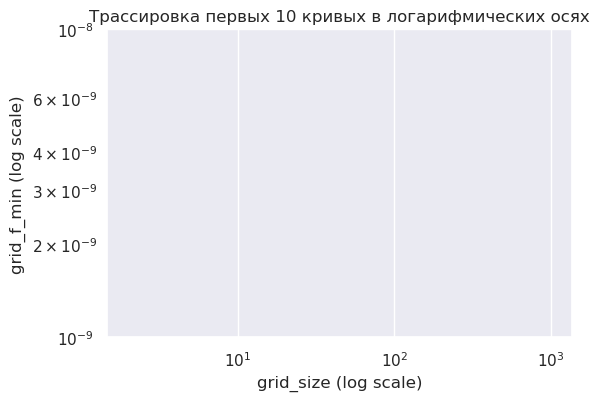

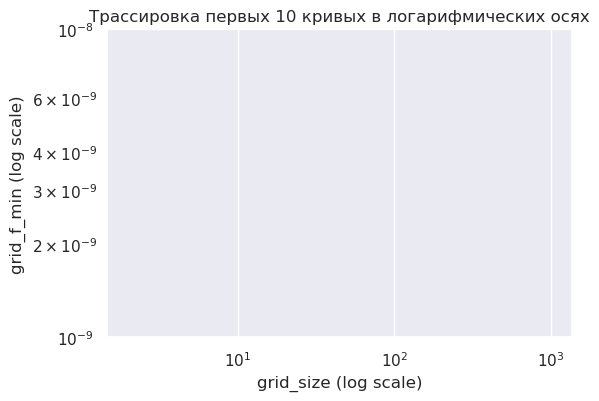

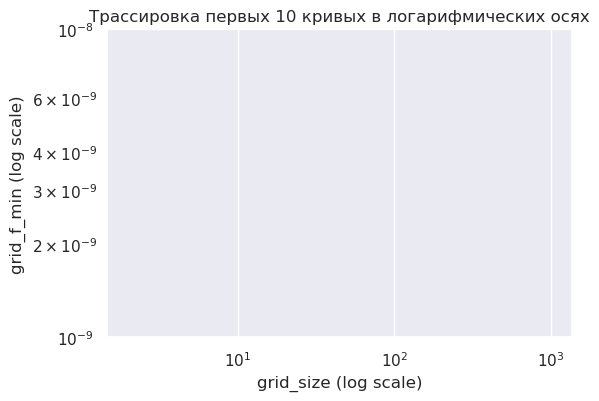

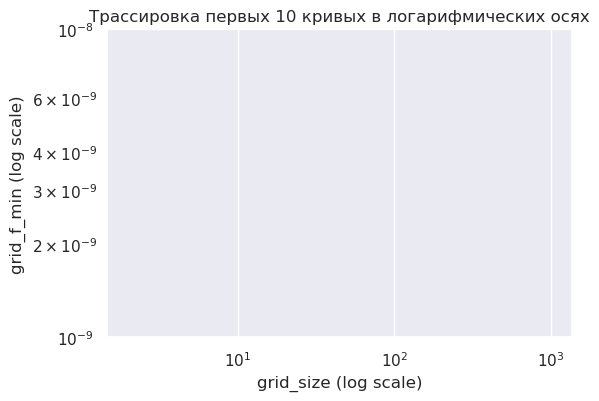

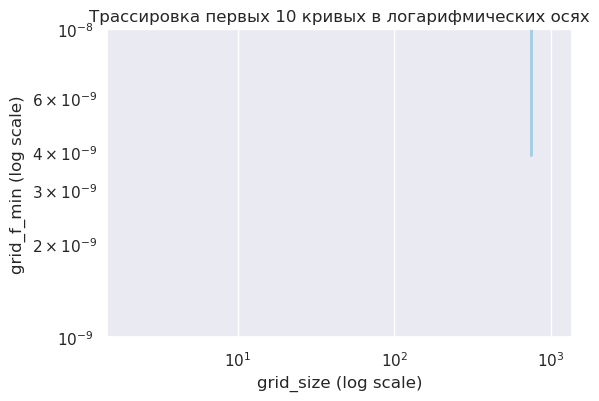

In [258]:
for grid_f_min in grid_min_f_trace[:10]:
    plt.figure(figsize=(6, 4))
    plt.plot(grid_size, grid_f_min)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("grid_size (log scale)")
    plt.ylabel("grid_f_min (log scale)")
    plt.title("Трассировка первых 10 кривых в логарифмических осях")
    plt.ylim(10 ** (-9), 10 ** (-8))
    plt.show()

In [261]:
print(f' Минимальное полученое значение: exp({np.min(grid_min_f_trace)})')

 Минимальное полученое значение: exp(3.092581746244605e-12)


Теперь рассмотрим **случайный поиск**. Снова проведем вычислительный эксперимент. Обратите внимание, что случайные точки для эксперимента мы генерируем один раз.

In [263]:
# рассматриваемое количество случайных точек
random_size = np.arange(2, 1000)

In [267]:
# массив для минимумов для текущего эксперимента
random_min_f_trace = []

# цикл по экспериментам
for _ in tqdm(range(n_experiments)):
    # случайное смещение на [-0.5, 0.5]
    x_0 = sps.uniform.rvs(loc=-0.5, scale=1)
    # массив для минимумов для текущего количества точек
    random_min_f = []
    # сгенерируем случайные на [-10, 10] точки сразу
    points = sps.uniform.rvs(loc=-10, scale=20, size=1000)

    #цикл по количеству точек
    for n in random_size:
        # найденный по первым n случайным точкам со смещением x_0 минимум функции f
        f_min = min(f(points[:n] + x_0))
        # сохранение результатов
        random_min_f.append(f_min)

    random_min_f_trace.append(random_min_f)

  0%|          | 0/100 [00:00<?, ?it/s]

Снова для нескольких экспериментов постройте графики значений минимума от количества точек при случайном поиске.

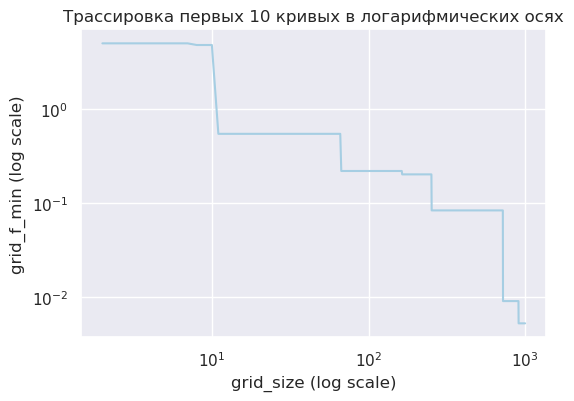

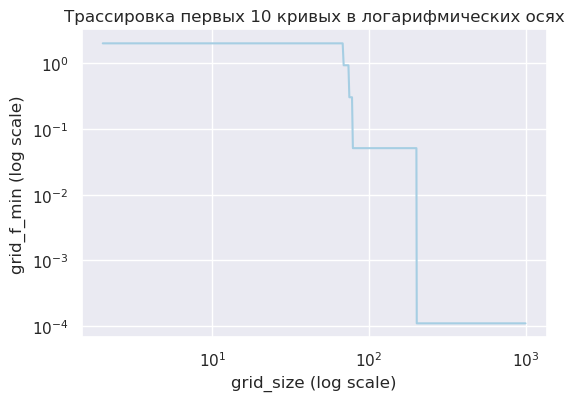

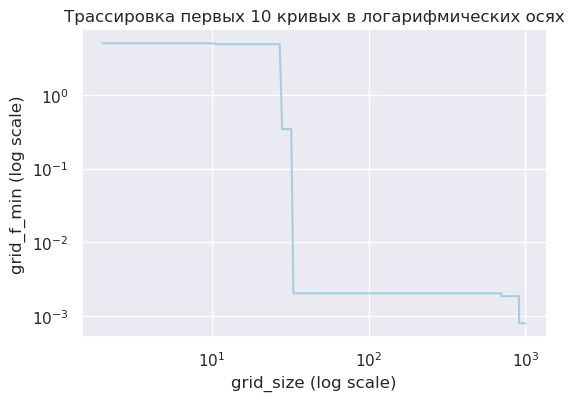

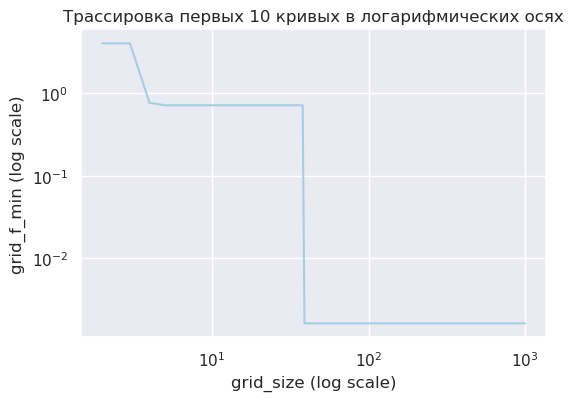

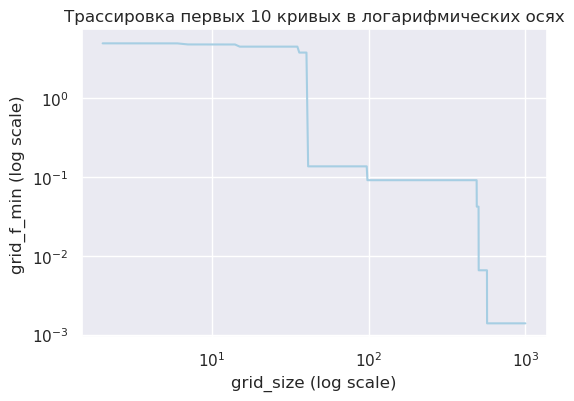

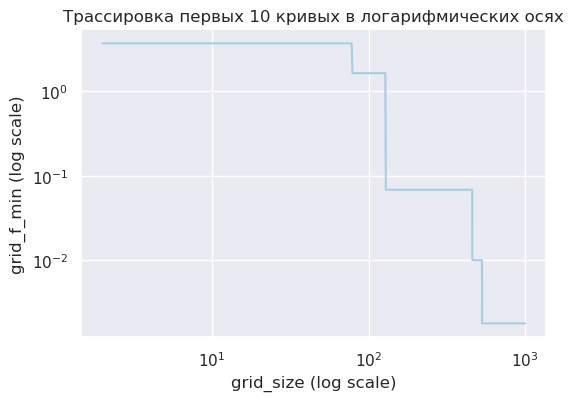

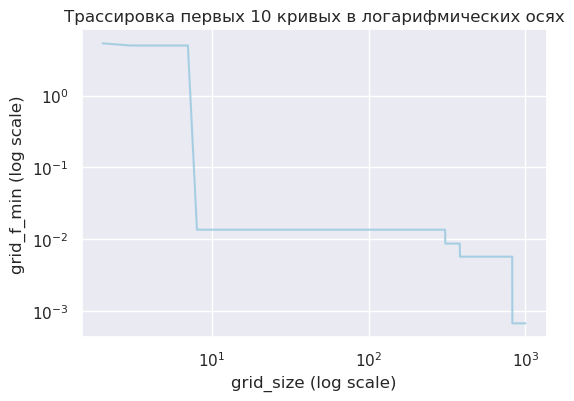

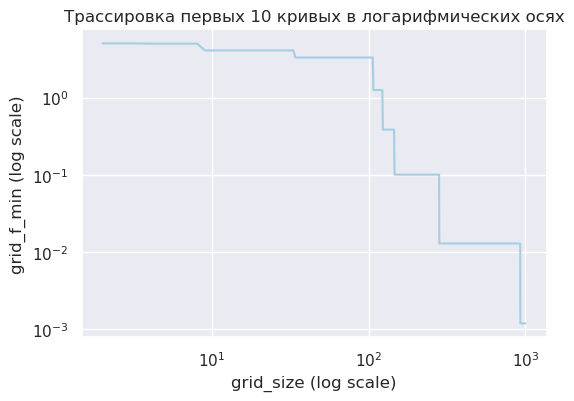

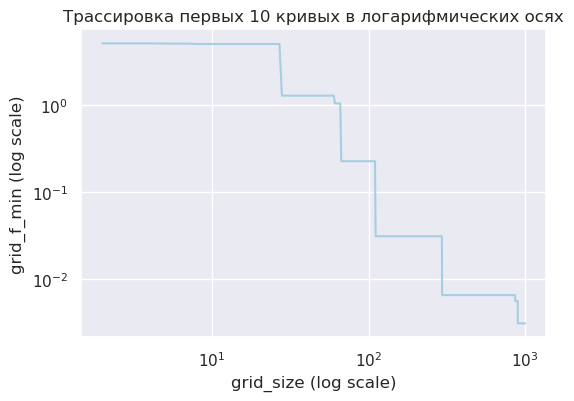

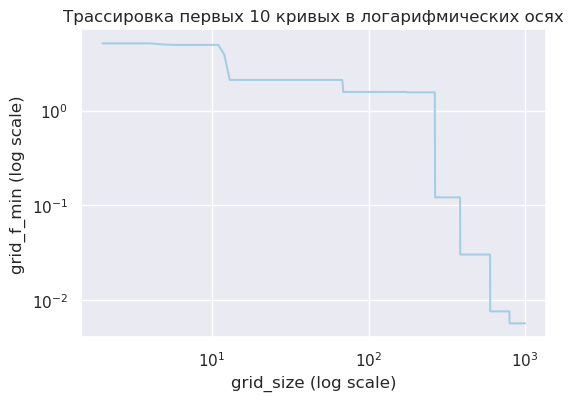

In [270]:
for random_min_f in random_min_f_trace[:10]:
    plt.figure(figsize=(6, 4))
    plt.plot(random_size, random_min_f)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("grid_size (log scale)")
    plt.ylabel("grid_f_min (log scale)")
    plt.title("Трассировка первых 10 кривых в логарифмических осях")
    plt.show()

Сравним два метода. Для этого постройте график зависимости найденного минимума от количества точек (случайных или в сетке). Перед этим предварительно усредните результат по количеству экспериментов. Какие результаты у вас получились?

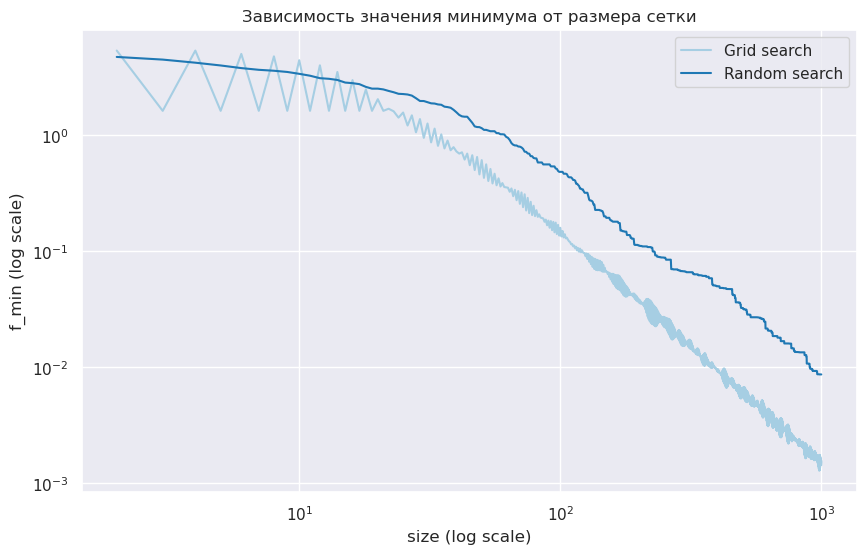

In [293]:
grid_min_f = np.mean(grid_min_f_trace, axis=0)
random_min_f = np.mean(random_min_f_trace, axis=0)

plt.plot(grid_size, grid_min_f, label='Grid search')
plt.plot(random_size, random_min_f, label='Random search')
plt.title('Зависимость значения минимума от размера сетки')
plt.xlabel("size (log scale)")
plt.ylabel("f_min (log scale)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

Теперь расмотрим **двумерный случай**, для этого определим следующую функцию:

In [337]:
def f(x, y,):
    return 5.4 - 5/(1+(3*x)**2) - np.cos(x)/5 - np.cos(y)/5

Постройте тепловую карту значений этой функции на $[-20, 20]^2$.

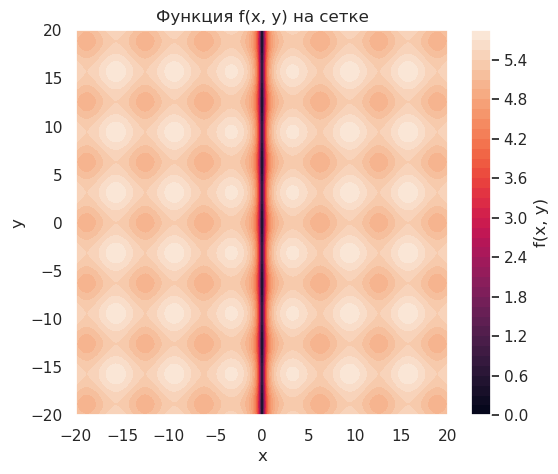

In [377]:
x, y = np.linspace(-20, 20, 1000), np.linspace(-20, 20, 1000)
X, Y = np.meshgrid(x, y)

plt.figure(figsize=(6, 5))
plt.contourf(X, Y, Z, levels=50)
plt.colorbar(label="f(x, y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Функция f(x, y) на сетке")
plt.show()

Проведите эксперимент, аналогичный одномерному случаю. В случае поиска по сетке рассмотрите сетку размера $n$ на $[-10, 10]$ по каждой координате. Таким образом, общий размер сетки будет $n^2$. Для ускорения вычислений в случае случайного поиска будет достаточно рассмотреть только такое количество точек, которое соответствует рассмотренным размерам сетки (т.е. квадраты чисел).

Сравните результат с полученным ранее. Сделайте вывод.

In [381]:
# рассматриваемые размеры сеток
grid_size = np.arange(2, 1000)
n_experiments = 10  # количество экспериментов
# массив для минимумов по сетке для текущего эксперимента
grid_min_f_trace = []

for _ in tqdm(range(n_experiments)):
    # случайное смещение сетки на [-0.5, 0.5]
    x_0, y_0 = sps.uniform.rvs(loc=-0.5, scale=1, size=2)
    # массив для минимумов для текущего размера сетки
    grid_f_min = []
    # цикл по размеру сетки
    for n in grid_size:
        # сетка на [-10, 10] размера n
        x, y = np.linspace(-10, 10, n), np.linspace(-10, 10, n)
        X, Y = np.meshgrid(x + x_0, y + y_0)
        # найденный по сетке со смещением x_0 минимум функции f
        f_min = np.min(f(X, Y))
        # сохраним минимум для сетки размера n
        grid_f_min.append(f_min)
    # сохраним минимумы текущего эксперимента
    grid_min_f_trace.append(grid_f_min)

  0%|          | 0/10 [00:00<?, ?it/s]

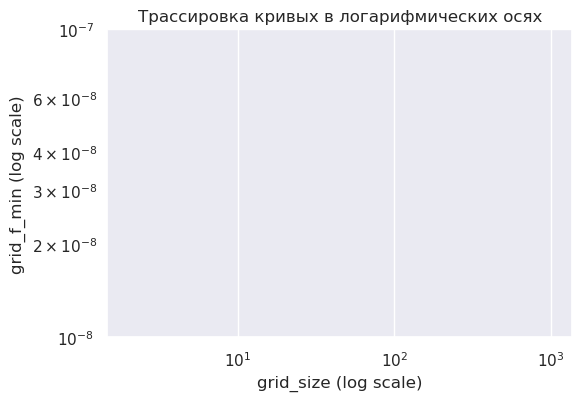

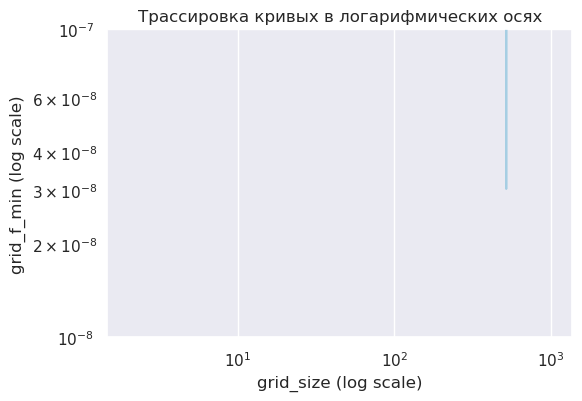

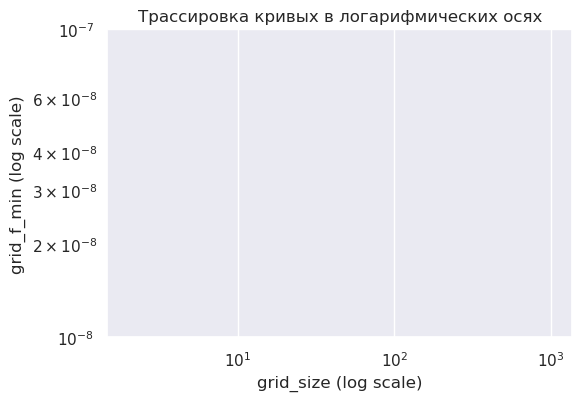

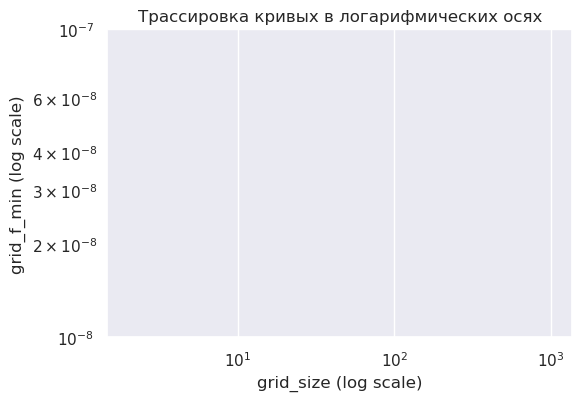

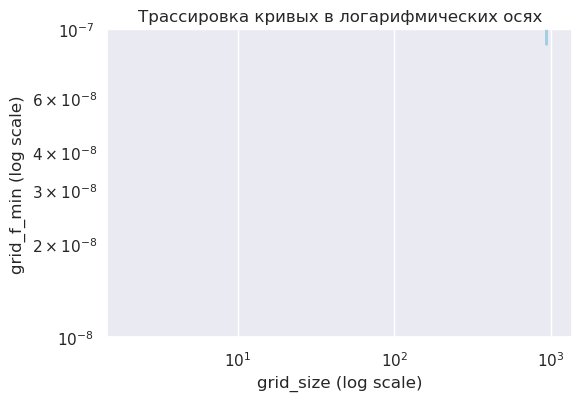

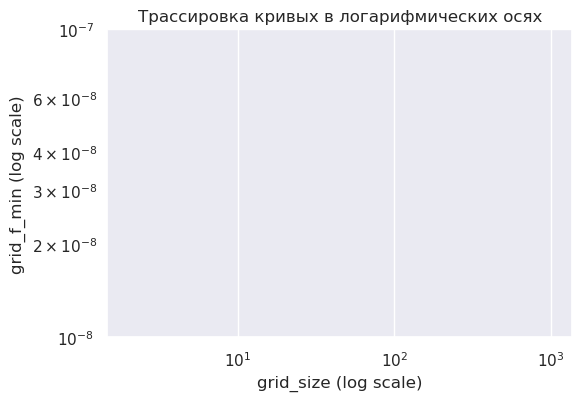

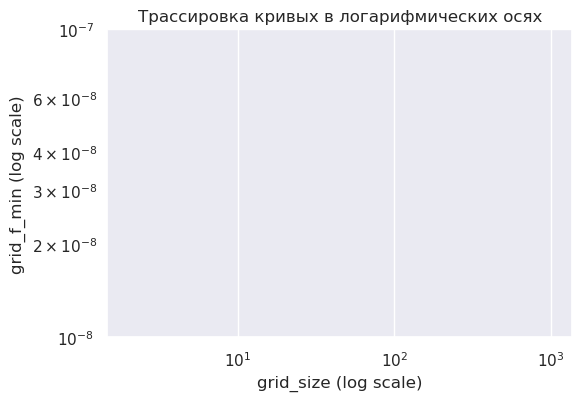

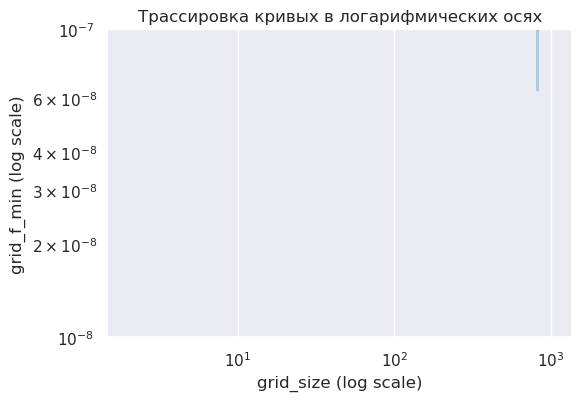

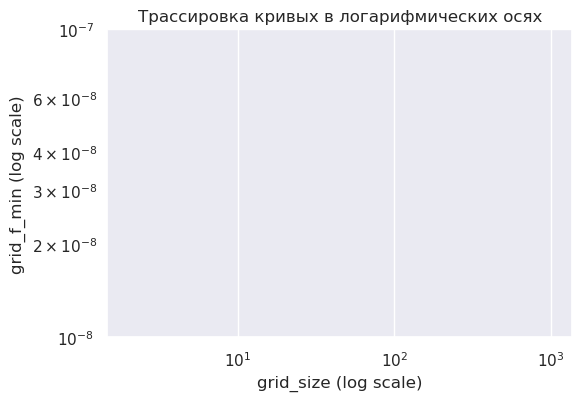

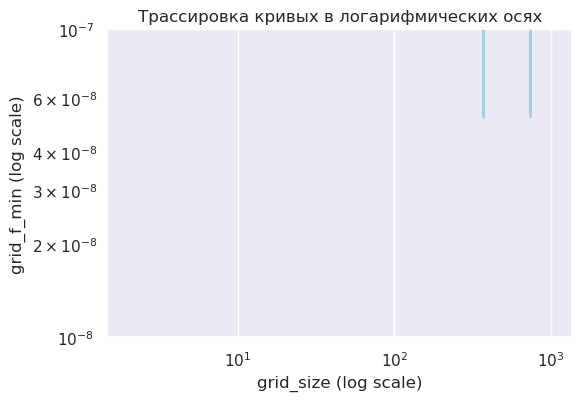

In [386]:
for grid_f_min in grid_min_f_trace:
    plt.figure(figsize=(6, 4))
    plt.plot(grid_size, grid_f_min)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("grid_size (log scale)")
    plt.ylabel("grid_f_min (log scale)")
    plt.title("Трассировка кривых в логарифмических осях")
    plt.ylim(10 ** (-8), 10 ** (-7))
    plt.show()

In [382]:
# массив для минимумов для текущего эксперимента
random_min_f_trace = []

# цикл по экспериментам
for _ in tqdm(range(n_experiments)):
    # случайное смещение на [-0.5, 0.5]
    x_0, y_0 = sps.uniform.rvs(loc=-0.5, scale=1, size=2)
    # массив для минимумов для текущего количества точек
    random_min_f = []
    # сгенерируем случайные на [-10, 10] точки сразу
    points = sps.uniform.rvs(loc=-10, scale=20, size=1000)

    #цикл по количеству точек
    for n in random_size:
        # найденный по первым n случайным точкам со смещением x_0 минимум функции f
        x, y = points[:n], points[:n]
        X, Y = np.meshgrid(x + x_0, y + y_0)
        f_min = np.min(f(X, Y))
        # сохранение результатов
        random_min_f.append(f_min)

    random_min_f_trace.append(random_min_f)

  0%|          | 0/10 [00:00<?, ?it/s]

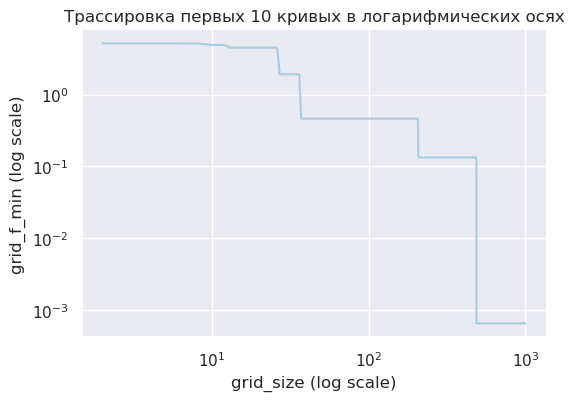

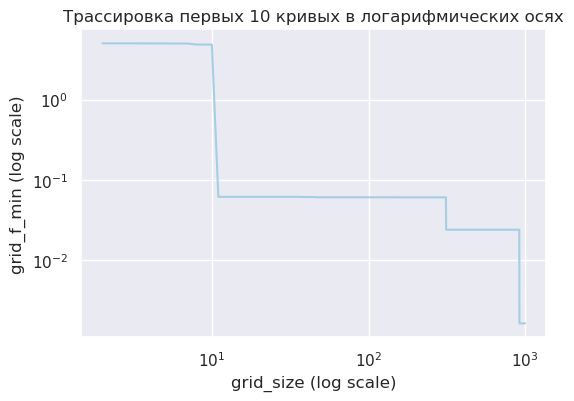

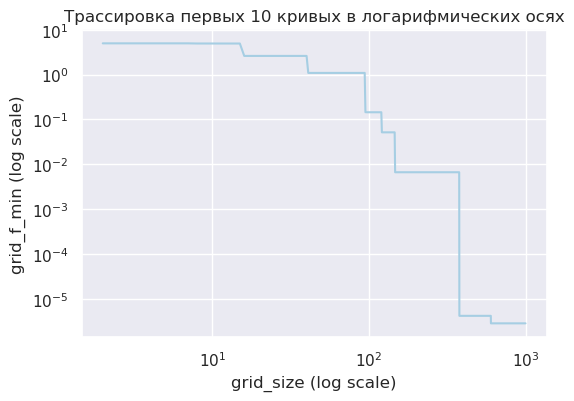

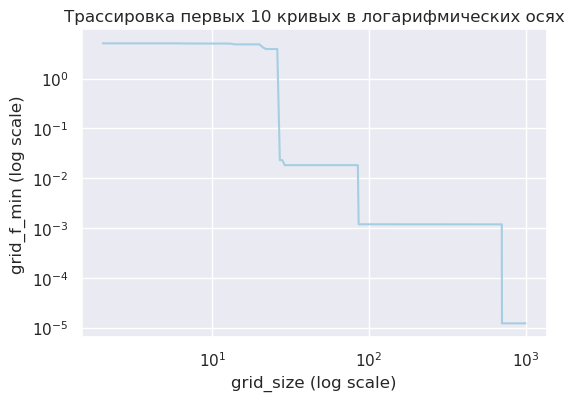

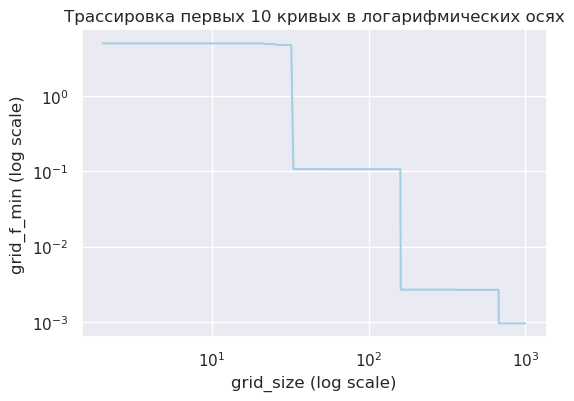

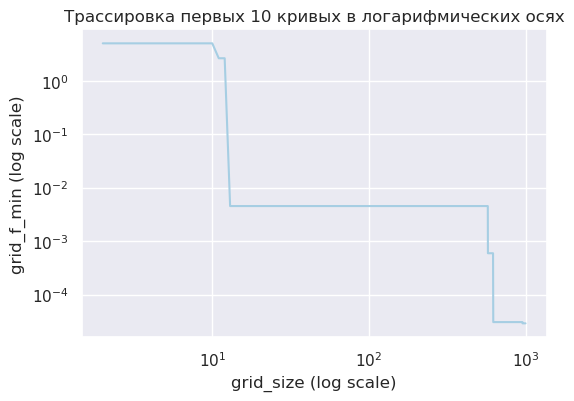

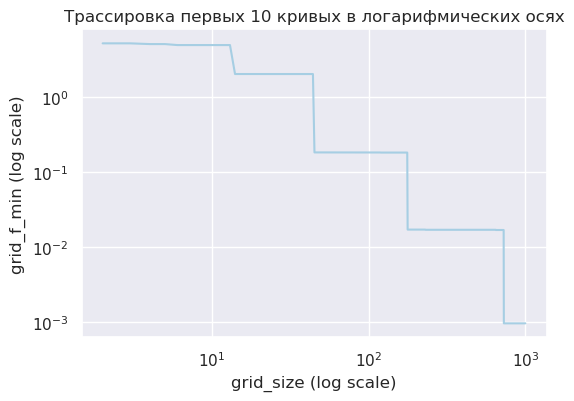

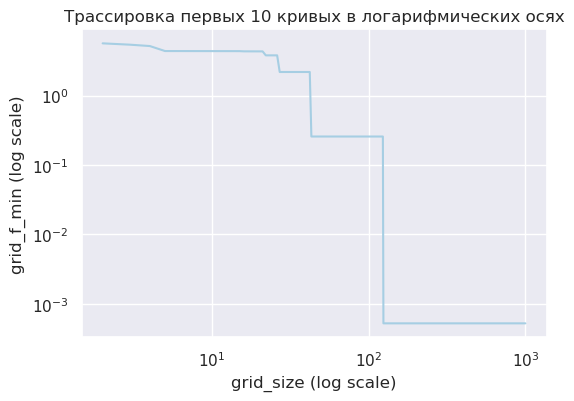

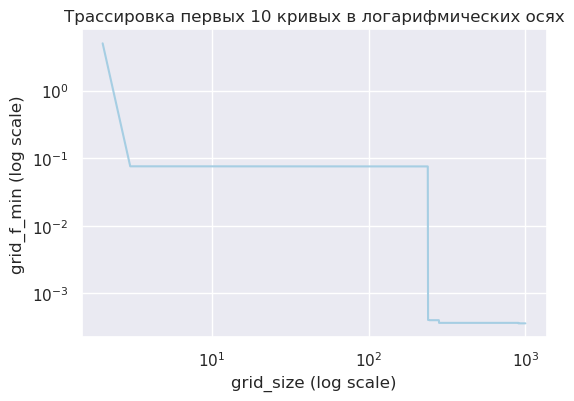

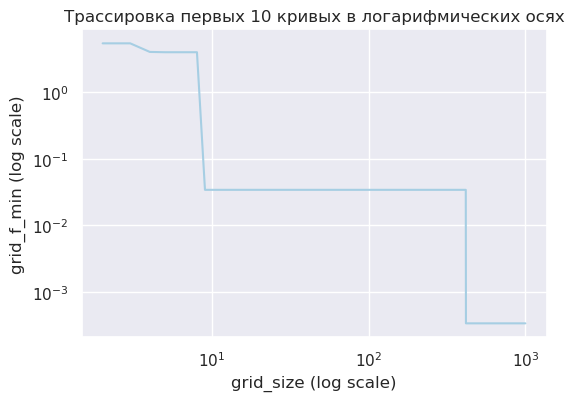

In [384]:
for random_min_f in random_min_f_trace:
    plt.figure(figsize=(6, 4))
    plt.plot(random_size, random_min_f)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("grid_size (log scale)")
    plt.ylabel("grid_f_min (log scale)")
    plt.title("Трассировка первых 10 кривых в логарифмических осях")
    plt.show()

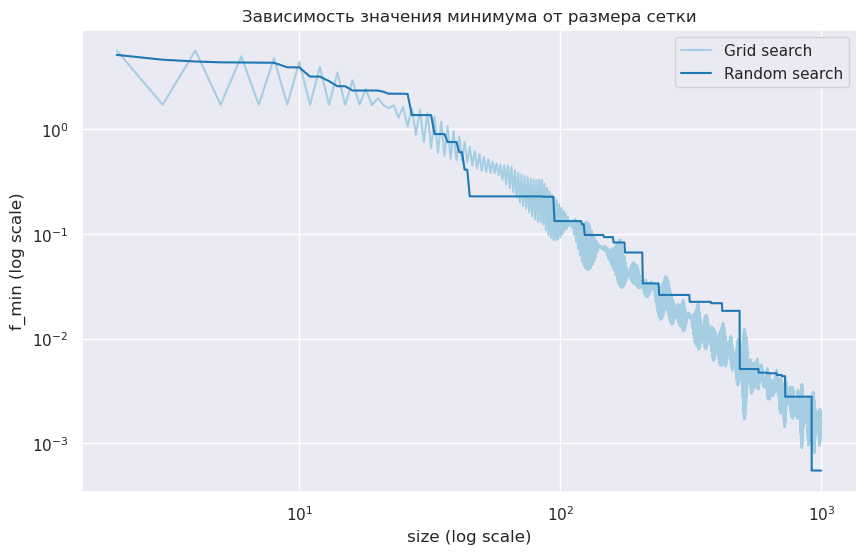

In [387]:
grid_min_f = np.mean(grid_min_f_trace, axis=0)
random_min_f = np.mean(random_min_f_trace, axis=0)

plt.plot(grid_size, grid_min_f, label='Grid search')
plt.plot(random_size, random_min_f, label='Random search')
plt.title('Зависимость значения минимума от размера сетки')
plt.xlabel("size (log scale)")
plt.ylabel("f_min (log scale)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

**Вывод:** Вывод: на наших экспериментах grid_search в среднем показал лучшую оптимизацию при размерности пространства 1 гиперпараметров, тогда как в размерности 2 random_search оказался быстрее и эффективнее. При росте числа параметров полная сетка становится чрезвычайно разреженной и вычислительно дорогой, а случайная выборка покрывает пространство лучше при ограниченном бюджете.

---
### Задача 5

Рассмотрим датасет для классификации дождливой погоды на завтра [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package). Датасет состоит из 145 тысяч объектов, таргетом является `RainTomorrow`. В данной задаче, используя этот датасет, вы научитесь пользоваться кросс-валидацией и подбирать оптимальные гиперпараметры модели.

Начнем с загрузки данных.

In [14]:
import kagglehub

# Скачиваем данные
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
data = pd.read_csv(os.path.join(path, 'weatherAUS.csv'))

data.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [44]:
data.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [46]:
data.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

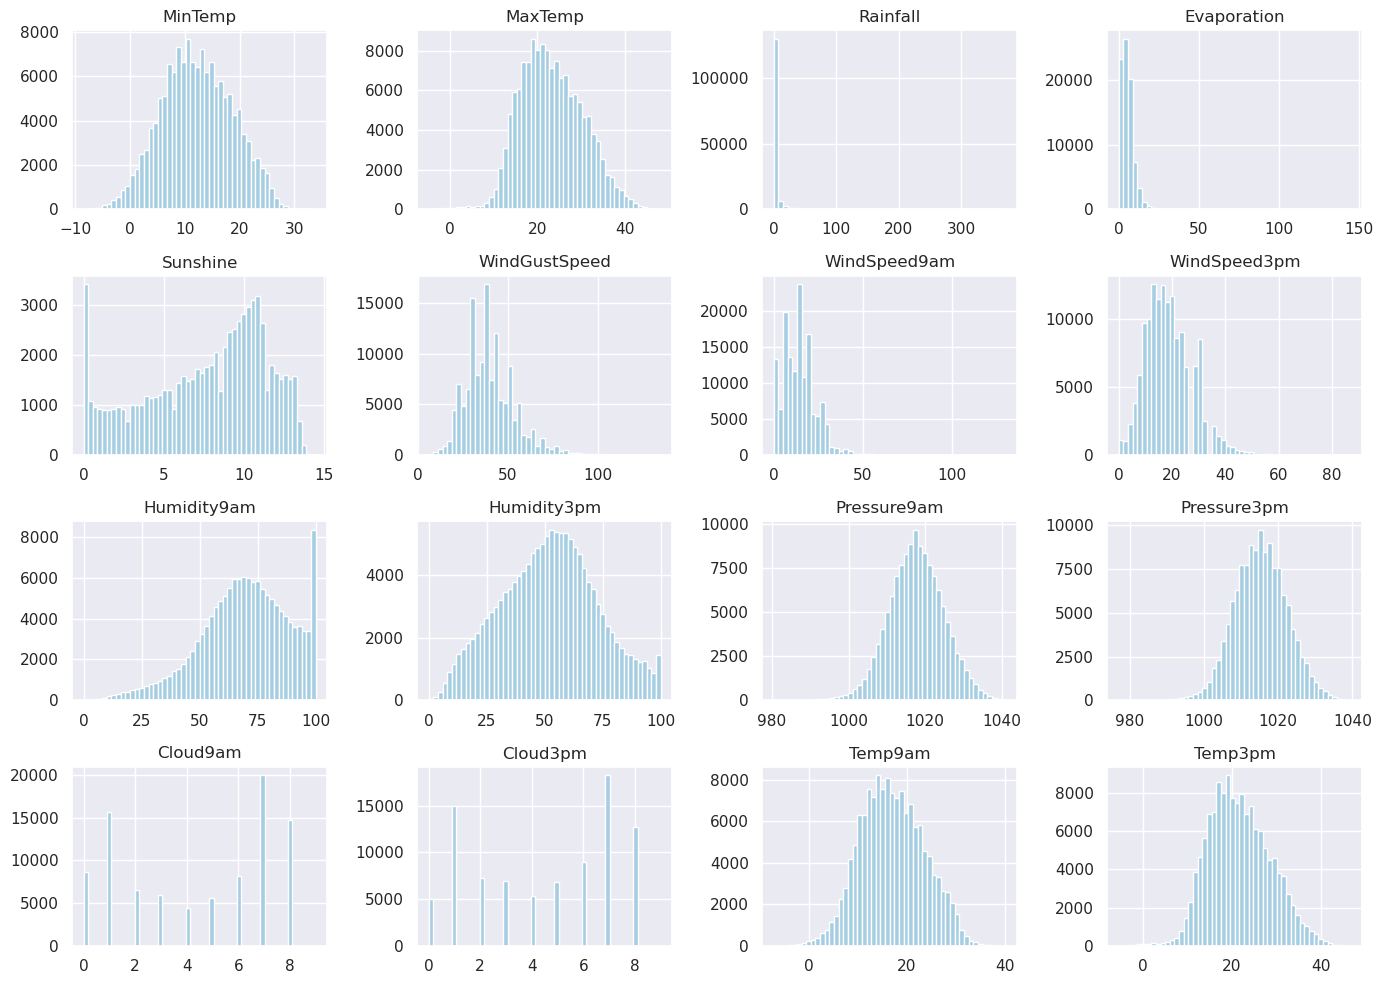

Количество уникальных значений в категориальном столбце Date: 3436
Количество уникальных значений в категориальном столбце Location: 49


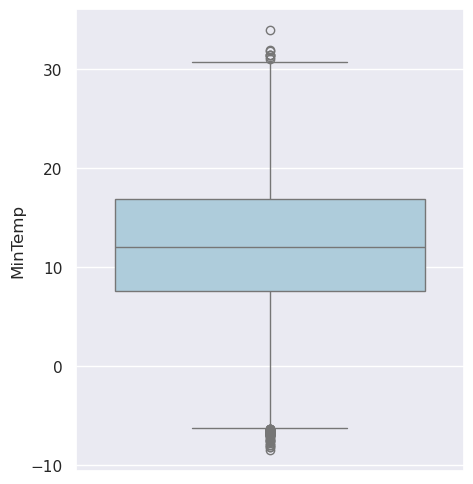

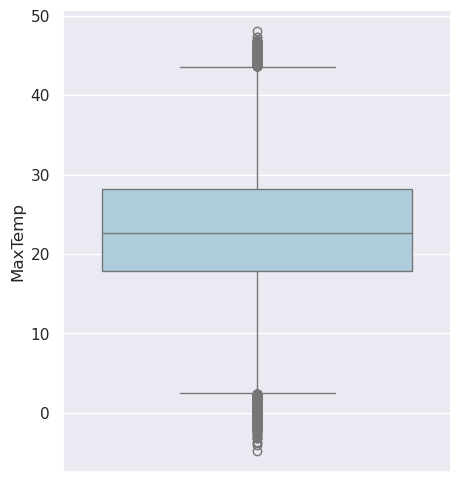

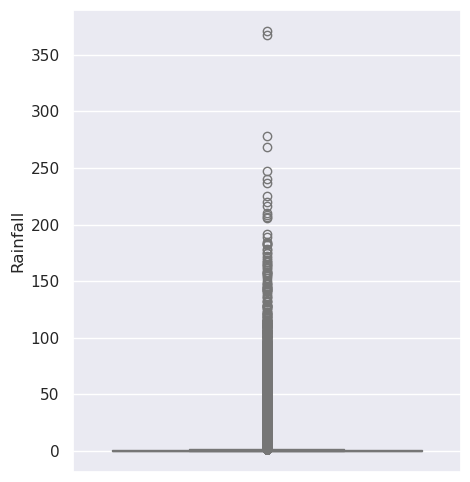

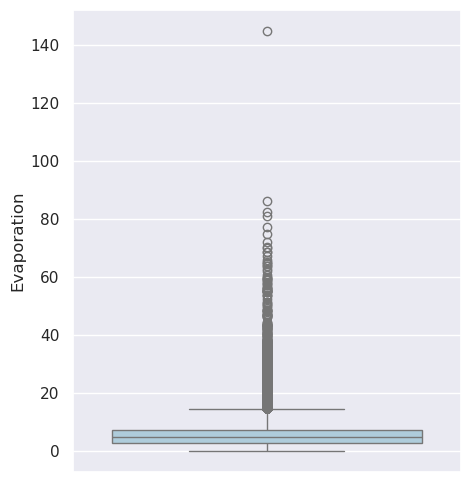

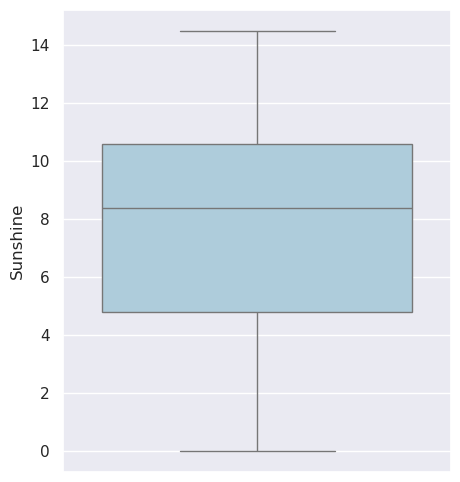

Количество уникальных значений в категориальном столбце WindGustDir: 16


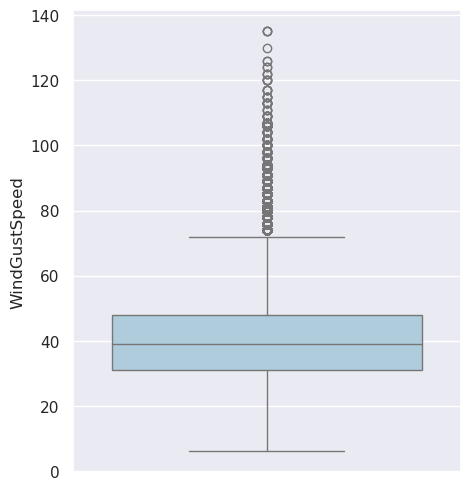

Количество уникальных значений в категориальном столбце WindDir9am: 16
Количество уникальных значений в категориальном столбце WindDir3pm: 16


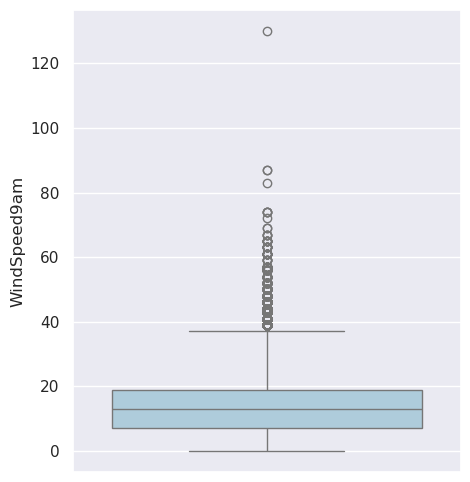

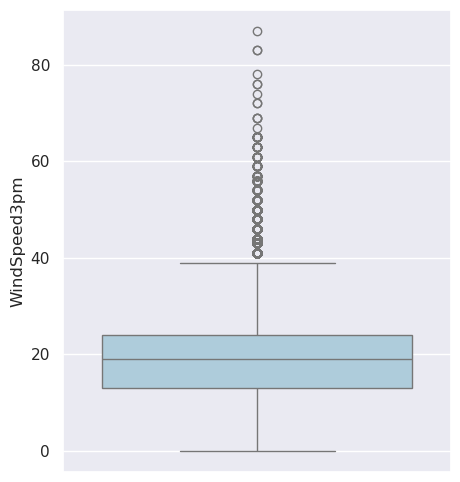

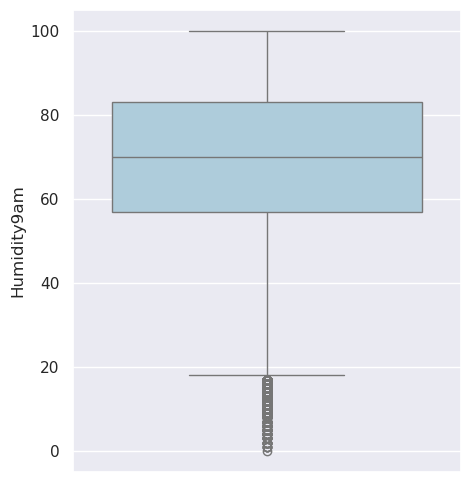

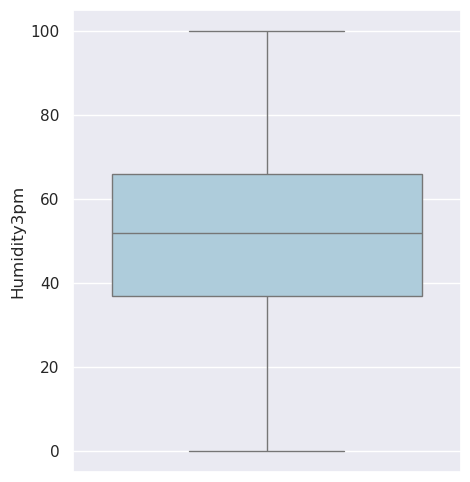

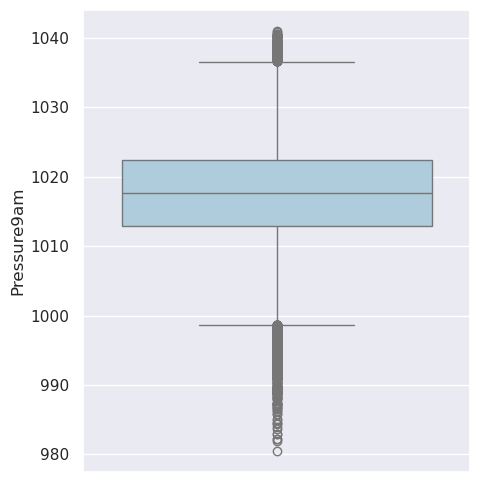

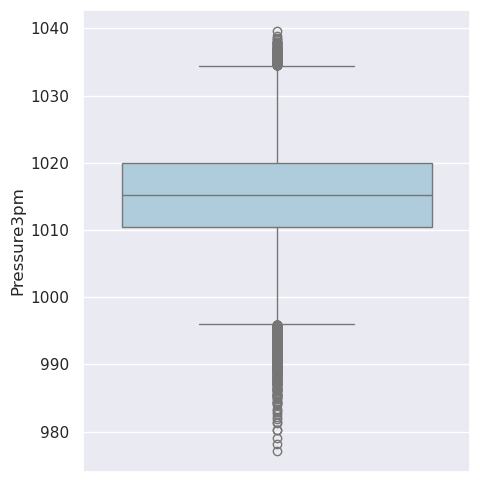

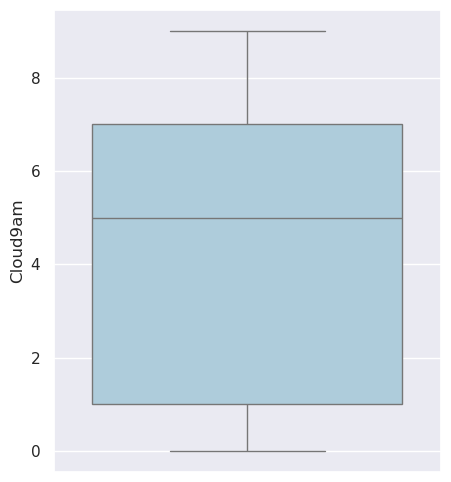

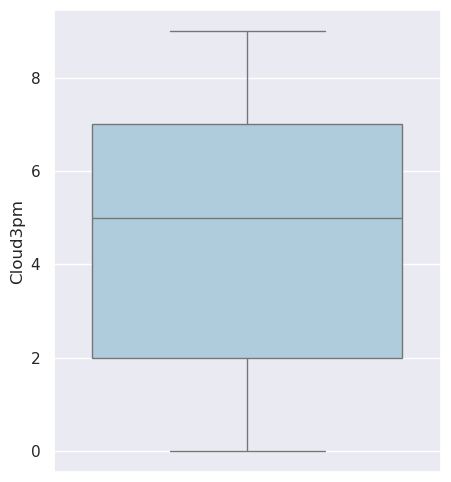

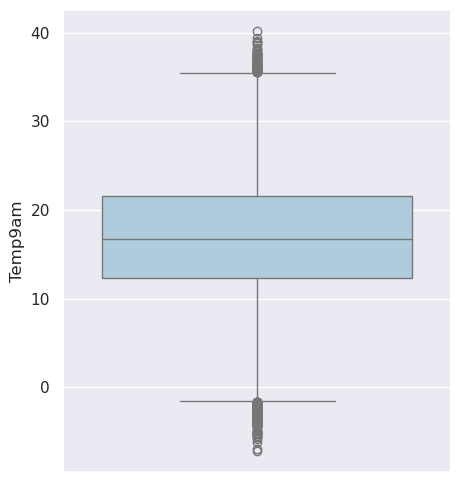

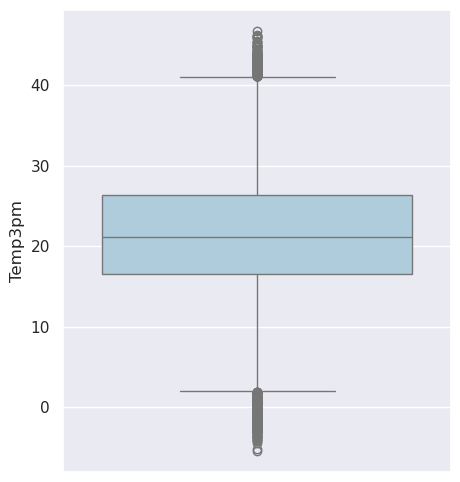

Количество уникальных значений в категориальном столбце RainToday: 2
Количество уникальных значений в категориальном столбце RainTomorrow: 2


In [47]:
data.hist(figsize=(14, 10), bins=50)
plt.tight_layout()
plt.show()


for column_name in data.columns:
    column = data.loc[:, column_name]
    if column.dtype == 'object':
        print(f'Количество уникальных значений в категориальном столбце {column_name}: {column.nunique()}')
        
    else:
        plt.figure(figsize=(5, 6))
        sns.boxplot(column)
        plt.show()

In [15]:
data['Date'] = pd.to_datetime(data['Date'])
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['day'] = data['Date'].dt.day
data = data.drop(['Date'], axis=1)

In [16]:
data = data.loc[~data.loc[:, 'RainTomorrow'].isna(), :]
bin_columns = ['RainTomorrow', 'RainToday']
data.loc[:, bin_columns] = (data.loc[:, bin_columns]=='Yes').astype(int)

In [17]:
imp_columns = ['MinTemp', 'MaxTemp', 'Rainfall', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Temp9am', 'Temp3pm']   
num_imputer = SimpleImputer(strategy='median')
data.loc[:, imp_columns] = num_imputer.fit_transform(data.loc[:, imp_columns])

In [18]:
ohe_loc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
loc_encoded = ohe_loc.fit_transform(data.loc[:, ['Location']])
data = data.drop(columns=['Location'])
data = pd.concat([data, pd.DataFrame(loc_encoded, columns=ohe_loc.get_feature_names_out(), index=data.index)], axis=1)

In [19]:
ohe_columns = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

data.loc[:, ohe_columns] = data.loc[:, ohe_columns].fillna('Unknown')

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(data.loc[:, ohe_columns])
data = data.drop(ohe_columns, axis=1)
data = pd.concat([data, pd.DataFrame(encoded, columns=ohe.get_feature_names_out(), index=data.index)], axis=1)

In [20]:
cols = ['Evaporation', 'Sunshine', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm'] 
imp = IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=RANDOM_STATE, n_jobs=N_JOBS), 
                       max_iter=5, random_state=RANDOM_STATE) 
data_imputed = imp.fit_transform(data[data.columns[:16].values])

/home/kirill/miniconda3/envs/DScource/lib/python3.10/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [21]:
data_imputed = pd.DataFrame(data_imputed, columns=data.columns[:16].values, index=data[data.columns[:16].values].index)
for c in cols:
    if c in ['Cloud9am','Cloud3pm']:
        vals = np.round(data_imputed[c]).astype(int)
        vals = np.clip(vals, 0, 9)
        data.loc[:, c] = pd.Series(vals, index=data.index).astype(int)
    else:
        data.loc[:, c] = data_imputed.loc[:, c]

In [25]:
np.unqiue(data.loc[])

0         0
1         0
2         0
3         0
4         0
         ..
145454    0
145455    0
145456    0
145457    0
145458    0
Name: RainToday, Length: 142193, dtype: object

**1.** Используя одну из стратегий кросс-валидации подберите оптимальные параметры обучения случайного леса &mdash; `n_estimators`, `max_depth` и `min_samples_split`. В качестве метрик используйте Accuracy и F1.

In [22]:
X, y = data.drop(['RainTomorrow'], axis=1), data.loc[:, ['RainTomorrow']].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
from sklearn.metrics import accuracy_score, f1_score

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_distributions = {
    'n_estimators': np.arange(50, 501, 5),
    'max_depth': np.arange(3, 31),
    'min_samples_split': np.arange(2, 26)
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=1,
    scoring='accuracy',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

In [1]:
import pandas as pd

In [ ]:
random_search.fit(X_train, y_train)
y_pred = random_search.predict(X_test)
print(accuracy_score(y_pred, y_test))

Дальше умирает kernel

Постройте графики зависимости метрик от максимальной глубины дерева. Значение `n_estimators` и `min_samples_split` фиксируйте.

In [ ]:
<...>

Постройте графики зависимости метрик от количества деревьев. Значение `max_depth` и `min_samples_split` фиксируйте.

In [ ]:
<...>

**2.** Рассмотрим модель с наилучшими гиперпараметрами из предыдущего пункта. Исследуем свойства различных подходов валидации. В качестве метрики используйте F1-метрику.

Выполните не менее 100 следующих итераций.
1. Перемешайте исходные данные.
2. Выполните подход с однократным разбиением:
    * разделите перемешанные даннные на обучающую и валидационную выборку,
    * обучите модель на обучающей выборке,
    * посчитайте качество модели на валидационной выборке и сохраните это значение.
3. Выполните KFold-валидацию:
    * примените KFold к перемешанным даннным, выполняя разбиение на 5 фолдов,
    * посчитайте среднее и дисперсию качества моделей по фолдам и сохраните эти значение.
4. Аналогично примените ShuffleSplit-валидацию, выполнив 5 ее итераций. На каждой итерации размер валидационной части должен совпадать с тем, который был использован в KFold. Иначе говоря, нужно использовать `ShuffleSplit(n_splits=5, test_size=0.2)`.
5. Повторите пункты 2-4 для стратифицированных разбиений.

*Проверьте, что на разных итерациях у вас получаются разные значения метрик. Если одинаковые, то может быть где-то нужно отключить `random_state`. Также советуем при отладке кода делать запуски на малое количество итераций.*

In [ ]:
<...>

По всем итерациям посчитайте
* выборочную дисперсию среднего качества моделей для каждого из трех подходов, тем самым оценив разброс значений метрик в каждом подходе;
* постройте kde-график среднего качества моделей;
* для подходов KFold и ShuffleSplit посчитайте выборочное среднее дисперсии качества моделей по фолдам, тем самым оценив разброс метрик между фолдами/итерациями.

In [ ]:
<...>

Сделайте выводы о свойствах подходов, их преимуществах и недостатках.

**Вывод:** <...>

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для DS-потока